# Load the dataset

In [149]:
import pandas as pd

# Load Excel file
file_path = "data to ankan final.xlsx"

# Read all sheets into a dictionary
sheets = pd.read_excel(file_path, sheet_name=None)

# Combine all sheets into one DataFrame
df = pd.concat(sheets.values(), ignore_index=True)

df

,Date,BOP-1 Flow,BOP-2 Flow,Dig-1 Solid,Dig-2 Solid,BOP-3 Flow,Dig-3 Solid,HRD-101 u/f Flow,HRD-102 u/f Flow,HRD-201 u/f Flow,HRD_301 u/f Flow,HRD-101 u/f Solid,HRD-102 u/f Solid,HRD-201 u/f Solid,HRD_301 u/f Solid
0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-04-01,1276.002731,1209.403343,113.333333,123.000000,1237.736125,124.000000,153.217391,105.869565,0.000000,0.000000e+00,688.666667,706.000000,0.000000,732.666667
2,2026-04-02,1339.874736,1280.039459,123.833333,119.000000,1224.690201,127.166667,152.625000,87.750000,0.000000,0.000000e+00,798.000000,799.000000,0.000000,770.000000
3,2026-04-03,1296.860835,1279.410172,131.833333,127.333333,1269.556569,125.500000,152.833333,78.428571,0.000000,1.425600e+02,802.333333,784.333333,0.000000,802.666667
4,2026-04-04,1297.886963,1275.317200,128.333333,126.833333,1336.679489,130.500000,155.458333,123.300000,0.000000,1.447925e+02,819.666667,804.333333,0.000000,803.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781,2025-03-27,1075.767004,1109.665084,126.400000,122.800000,693.818907,130.333333,154.083553,184.036644,121.522846,5.273003e-03,783.000000,807.333333,787.000000,0.000000
782,2025-03-28,-,0.000000,0.000000,0.000000,0.000000,0.000000,21.606020,23.310416,0.069090,5.273003e-03,0.000000,0.000000,0.000000,0.000000
783,2025-03-29,130.791351,295.194519,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
784,2025-03-30,860.506152,530.088997,102.800000,123.500000,914.559337,110.250000,35.386435,108.806698,80.031526,3.576444e-37,701.000000,739.000000,512.000000,0.000000


In [150]:
df.iloc[1:].reset_index(drop=True)

,Date,BOP-1 Flow,BOP-2 Flow,Dig-1 Solid,Dig-2 Solid,BOP-3 Flow,Dig-3 Solid,HRD-101 u/f Flow,HRD-102 u/f Flow,HRD-201 u/f Flow,HRD_301 u/f Flow,HRD-101 u/f Solid,HRD-102 u/f Solid,HRD-201 u/f Solid,HRD_301 u/f Solid
0,2026-04-01,1276.002731,1209.403343,113.333333,123.000000,1237.736125,124.000000,153.217391,105.869565,0.000000,0.000000e+00,688.666667,706.000000,0.000000,732.666667
1,2026-04-02,1339.874736,1280.039459,123.833333,119.000000,1224.690201,127.166667,152.625000,87.750000,0.000000,0.000000e+00,798.000000,799.000000,0.000000,770.000000
2,2026-04-03,1296.860835,1279.410172,131.833333,127.333333,1269.556569,125.500000,152.833333,78.428571,0.000000,1.425600e+02,802.333333,784.333333,0.000000,802.666667
3,2026-04-04,1297.886963,1275.317200,128.333333,126.833333,1336.679489,130.500000,155.458333,123.300000,0.000000,1.447925e+02,819.666667,804.333333,0.000000,803.666667
4,2026-04-05,1248.206558,1279.483226,127.000000,123.166667,1365.017726,126.500000,194.958333,99.391304,0.000000,1.537619e+02,776.000000,792.333333,0.000000,780.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
780,2025-03-27,1075.767004,1109.665084,126.400000,122.800000,693.818907,130.333333,154.083553,184.036644,121.522846,5.273003e-03,783.000000,807.333333,787.000000,0.000000
781,2025-03-28,-,0.000000,0.000000,0.000000,0.000000,0.000000,21.606020,23.310416,0.069090,5.273003e-03,0.000000,0.000000,0.000000,0.000000
782,2025-03-29,130.791351,295.194519,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
783,2025-03-30,860.506152,530.088997,102.800000,123.500000,914.559337,110.250000,35.386435,108.806698,80.031526,3.576444e-37,701.000000,739.000000,512.000000,0.000000


In [151]:
hrd_cols = [
    'HRD-101 u/f Flow',
    'HRD-102 u/f Flow',
    'HRD-201 u/f Flow',
    'HRD_301 u/f Flow'
]

# ✅ Check how many rows will be removed
for col in hrd_cols:
    neg_count = (df[col] < 0).sum()
    print(f"{col}: {neg_count} negative values")

# ✅ Drop rows where ANY HRD has negative value
df = df[(df[hrd_cols] >= 0).all(axis=1)].reset_index(drop=True)

HRD-101 u/f Flow: 33 negative values
HRD-102 u/f Flow: 45 negative values
HRD-201 u/f Flow: 0 negative values
HRD_301 u/f Flow: 64 negative values


# Identify the offline HRD

In [152]:
import numpy as np
import pandas as pd

hrd_cols = [
    'HRD-101 u/f Flow',
    'HRD-102 u/f Flow',
    'HRD-201 u/f Flow',
    'HRD_301 u/f Flow'
]

# ✅ Step 0: Convert low flow → NaN
for col in hrd_cols:
    df.loc[df[col] < 50, col] = np.nan

# ✅ Step 1: Define offline
for col in hrd_cols:
    df[f'{col}_offline'] = df[col].isna()

# ✅ Step 2: Count ONLINE HRDs
df['online_count'] = (~df[[f'{c}_offline' for c in hrd_cols]]).sum(axis=1)

# ✅ Step 3: Keep exactly 3 HRDs online
df = df[df['online_count'] == 3].copy()

# ✅ Step 4: Cleanup
df.drop(columns=[f'{c}_offline' for c in hrd_cols] + ['online_count'], inplace=True)

In [153]:
cols_to_drop = [
    'HRD-101 u/f Flow_offline',
    'HRD-102 u/f Flow_offline',
    'HRD-201 u/f Flow_offline',
    'HRD_301 u/f Flow_offline',
    'online_count'
]

df = df.drop(columns=cols_to_drop, errors='ignore')

In [154]:
cols = df.columns.drop('Date')

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# Clean the dataset

In [155]:
num_cols = df.select_dtypes(include='number').columns

In [156]:
percentiles = {}

for col in num_cols:
    p5 = df[col].quantile(0.05)
    p95 = df[col].quantile(0.95)
    
    percentiles[col] = {'p5': p5, 'p95': p95}

# Convert to DataFrame for clean view
percentiles_df = pd.DataFrame(percentiles).T

print(percentiles_df)

                            p5          p95
BOP-1 Flow         1070.893685  1355.756717
BOP-2 Flow         1029.210494  1293.655994
Dig-1 Solid         124.833333   132.500000
Dig-2 Solid         124.833333   133.008333
BOP-3 Flow         1166.749659  1371.643580
Dig-3 Solid         125.000000   132.333333
HRD-101 u/f Flow    134.994224   174.280291
HRD-102 u/f Flow    106.117786   168.430366
HRD-201 u/f Flow    122.805674   160.386708
HRD_301 u/f Flow    127.146180   163.873337
HRD-101 u/f Solid     0.000000   810.050000
HRD-102 u/f Solid     0.000000   809.016667
HRD-201 u/f Solid     0.000000   810.025000
HRD_301 u/f Solid     0.000000   815.666667


In [157]:
y_cols = [
    'HRD-101 u/f Solid',
    'HRD-102 u/f Solid',
    'HRD-201 u/f Solid',
    'HRD_301 u/f Solid'
]

# Start with full True mask
mask = True

for col in y_cols:
    p5 = df[col].quantile(0.05)
    p95 = df[col].quantile(0.95)

    mask &= df[col].between(p5, p95)

# Apply filter
df = df[mask].copy()

In [158]:
df

,Date,BOP-1 Flow,BOP-2 Flow,Dig-1 Solid,Dig-2 Solid,BOP-3 Flow,Dig-3 Solid,HRD-101 u/f Flow,HRD-102 u/f Flow,HRD-201 u/f Flow,HRD_301 u/f Flow,HRD-101 u/f Solid,HRD-102 u/f Solid,HRD-201 u/f Solid,HRD_301 u/f Solid
2,2026-04-03,1296.860835,1279.410172,131.833333,127.333333,1269.556569,125.500000,152.833333,78.428571,NaN,142.559996,802.333333,784.333333,0.000000,802.666667
4,2026-04-05,1248.206558,1279.483226,127.000000,123.166667,1365.017726,126.500000,194.958333,99.391304,NaN,153.761914,776.000000,792.333333,0.000000,780.666667
8,2026-04-09,1288.682602,1220.394887,127.333333,128.333333,1318.608068,127.666667,140.666667,101.000000,NaN,144.874333,781.333333,779.666667,0.000000,802.333333
10,2026-04-11,1246.845617,1242.579397,126.500000,127.500000,1322.277746,129.166667,168.916667,92.000000,NaN,146.945219,784.000000,784.000000,0.000000,796.333333
12,2026-04-13,1185.114171,1207.279521,128.500000,127.000000,1315.899821,126.166667,142.333333,74.200000,NaN,143.517326,808.000000,783.666667,0.000000,781.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
634,2025-03-23,1266.858673,1182.400386,129.500000,128.166667,1167.499262,131.500000,155.081548,142.964243,152.175386,NaN,771.333333,781.000000,796.333333,0.000000
636,2025-03-25,1254.116491,1229.004166,128.666667,129.666667,1129.309423,127.333333,152.748789,152.028478,149.474468,NaN,790.000000,794.000000,780.666667,0.000000
637,2025-03-26,1255.135152,1211.192724,129.833333,128.666667,1146.481984,129.333333,148.545720,162.038832,152.092041,NaN,783.666667,790.333333,793.333333,0.000000
638,2025-03-27,1075.767004,1109.665084,126.400000,122.800000,693.818907,130.333333,154.083553,184.036644,121.522846,NaN,783.000000,807.333333,787.000000,0.000000


In [159]:
# All other numeric columns = X
x_cols = [col for col in df.select_dtypes(include='number').columns if col not in y_cols]
for col in x_cols:
    p5 = df[col].quantile(0.05)
    p95 = df[col].quantile(0.95)

    df[col] = df[col].clip(lower=p5, upper=p95)

In [160]:
df[x_cols].describe()

,BOP-1 Flow,BOP-2 Flow,Dig-1 Solid,Dig-2 Solid,BOP-3 Flow,Dig-3 Solid,HRD-101 u/f Flow,HRD-102 u/f Flow,HRD-201 u/f Flow,HRD_301 u/f Flow
count,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,301.000000,316.000000,273.000000,385.000000
mean,1253.034738,1188.912926,128.402062,128.584667,1277.266293,128.579345,153.577447,145.782770,142.950488,144.602053
std,74.830832,70.138656,2.057800,2.181523,63.931175,1.958615,11.292711,13.309113,10.938188,10.036249
min,1078.440647,1025.305968,124.833333,124.866667,1163.494662,125.000000,135.239665,121.110813,122.274481,127.165726
25%,1214.230555,1151.187464,127.000000,127.000000,1222.905741,127.333333,144.885303,136.023296,134.444397,137.940653
50%,1265.582713,1199.491104,128.333333,128.500000,1283.509450,128.500000,153.478227,145.867639,144.335563,143.885004
75%,1307.686025,1236.304169,129.666667,129.833333,1330.565730,129.833333,161.643509,155.049647,151.219234,152.080625
max,1355.896690,1291.315194,132.500000,133.166667,1374.316453,132.333333,174.953404,171.995750,160.363591,163.933285


In [161]:
for col in x_cols:
    if not pd.api.types.is_numeric_dtype(df[col]):
        continue
    
    p5 = df[col].quantile(0.05)
    p95 = df[col].quantile(0.95)

    df[col] = df[col].clip(lower=p5, upper=p95)

In [162]:
df.describe()

,Date,BOP-1 Flow,BOP-2 Flow,Dig-1 Solid,Dig-2 Solid,BOP-3 Flow,Dig-3 Solid,HRD-101 u/f Flow,HRD-102 u/f Flow,HRD-201 u/f Flow,HRD_301 u/f Flow,HRD-101 u/f Solid,HRD-102 u/f Solid,HRD-201 u/f Solid,HRD_301 u/f Solid
count,425,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000,301.000000,316.000000,273.000000,385.000000,425.000000,425.000000,425.000000,425.000000
mean,2025-04-22 09:08:53.647058,1253.043364,1188.917782,128.402062,128.586047,1277.268445,128.579345,153.577447,145.784151,142.955046,144.602367,556.008627,581.937961,515.572353,714.598627
min,2024-04-03 00:00:00,1078.637139,1025.732764,124.833333,124.893333,1163.546614,125.000000,135.239665,121.169226,122.372602,127.219727,0.000000,0.000000,0.000000,0.000000
25%,2024-11-10 00:00:00,1214.230555,1151.187464,127.000000,127.000000,1222.905741,127.333333,144.885303,136.023296,134.444397,137.940653,0.000000,0.000000,0.000000,778.000000
50%,2025-04-26 00:00:00,1265.582713,1199.491104,128.333333,128.500000,1283.509450,128.500000,153.478227,145.867639,144.335563,143.885004,778.000000,777.666667,781.000000,791.333333
75%,2025-10-18 00:00:00,1307.686025,1236.304169,129.666667,129.833333,1330.565730,129.833333,161.643509,155.049647,151.219234,152.080625,791.666667,788.333333,793.000000,801.000000
max,2026-05-21 00:00:00,1355.866829,1290.982196,132.500000,133.166667,1374.306078,132.333333,174.953404,171.964604,160.354345,163.885327,810.000000,809.000000,809.666667,815.666667
std,NaN,74.804924,70.061840,2.057800,2.179172,63.925562,1.958615,11.292711,13.300502,10.927900,10.026560,355.695181,339.812623,375.499402,234.325460


# Build the features

In [163]:
df['delta_flow_HRD101'] = np.nan
df['delta_flow_HRD102'] = np.nan
df['delta_flow_HRD201'] = np.nan
df['delta_flow_HRD301'] = np.nan

In [164]:
# HRD201 off
mask = df['HRD-201 u/f Flow'].isna()

df.loc[mask, 'delta_flow_HRD101'] = df.loc[mask, 'BOP-1 Flow'] - df.loc[mask, 'HRD-101 u/f Flow']
df.loc[mask, 'delta_flow_HRD102'] = df.loc[mask, 'BOP-2 Flow'] - df.loc[mask, 'HRD-102 u/f Flow']
df.loc[mask, 'delta_flow_HRD301'] = df.loc[mask, 'BOP-3 Flow'] - df.loc[mask, 'HRD_301 u/f Flow']

In [165]:
# HRD102 off
mask = df['HRD-102 u/f Flow'].isna()

df.loc[mask, 'delta_flow_HRD101'] = df.loc[mask, 'BOP-1 Flow'] - df.loc[mask, 'HRD-101 u/f Flow']
df.loc[mask, 'delta_flow_HRD201'] = df.loc[mask, 'BOP-2 Flow'] - df.loc[mask, 'HRD-201 u/f Flow']
df.loc[mask, 'delta_flow_HRD301'] = df.loc[mask, 'BOP-3 Flow'] - df.loc[mask, 'HRD_301 u/f Flow']

In [166]:
# HRD101 off
mask = df['HRD-101 u/f Flow'].isna()

df.loc[mask, 'delta_flow_HRD102'] = df.loc[mask, 'BOP-1 Flow'] - df.loc[mask, 'HRD-102 u/f Flow']
df.loc[mask, 'delta_flow_HRD201'] = df.loc[mask, 'BOP-2 Flow'] - df.loc[mask, 'HRD-201 u/f Flow']
df.loc[mask, 'delta_flow_HRD301'] = df.loc[mask, 'BOP-3 Flow'] - df.loc[mask, 'HRD_301 u/f Flow']

In [167]:
#HRD301 off
mask = df['HRD_301 u/f Flow'].isna()

df.loc[mask, 'delta_flow_HRD101'] = df.loc[mask, 'BOP-1 Flow'] - df.loc[mask, 'HRD-101 u/f Flow']
df.loc[mask, 'delta_flow_HRD102'] = df.loc[mask, 'BOP-2 Flow'] - df.loc[mask, 'HRD-102 u/f Flow']
df.loc[mask, 'delta_flow_HRD201'] = df.loc[mask, 'BOP-3 Flow'] - df.loc[mask, 'HRD-201 u/f Flow']

In [168]:
df

,Date,BOP-1 Flow,BOP-2 Flow,Dig-1 Solid,Dig-2 Solid,BOP-3 Flow,Dig-3 Solid,HRD-101 u/f Flow,HRD-102 u/f Flow,HRD-201 u/f Flow,HRD_301 u/f Flow,HRD-101 u/f Solid,HRD-102 u/f Solid,HRD-201 u/f Solid,HRD_301 u/f Solid,delta_flow_HRD101,delta_flow_HRD102,delta_flow_HRD201,delta_flow_HRD301
2,2026-04-03,1296.860835,1279.410172,131.833333,127.333333,1269.556569,125.500000,152.833333,121.169226,NaN,142.559996,802.333333,784.333333,0.000000,802.666667,1144.027501,1158.240946,NaN,1126.996573
4,2026-04-05,1248.206558,1279.483226,127.000000,124.893333,1365.017726,126.500000,174.953404,121.169226,NaN,153.761914,776.000000,792.333333,0.000000,780.666667,1073.253154,1158.314000,NaN,1211.255812
8,2026-04-09,1288.682602,1220.394887,127.333333,128.333333,1318.608068,127.666667,140.666667,121.169226,NaN,144.874333,781.333333,779.666667,0.000000,802.333333,1148.015935,1099.225662,NaN,1173.733735
10,2026-04-11,1246.845617,1242.579397,126.500000,127.500000,1322.277746,129.166667,168.916667,121.169226,NaN,146.945219,784.000000,784.000000,0.000000,796.333333,1077.928950,1121.410171,NaN,1175.332527
12,2026-04-13,1185.114171,1207.279521,128.500000,127.000000,1315.899821,126.166667,142.333333,121.169226,NaN,143.517326,808.000000,783.666667,0.000000,781.666667,1042.780838,1086.110295,NaN,1172.382495
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
634,2025-03-23,1266.858673,1182.400386,129.500000,128.166667,1167.499262,131.500000,155.081548,142.964243,152.175386,NaN,771.333333,781.000000,796.333333,0.000000,1111.777125,1039.436143,1015.323876,NaN
636,2025-03-25,1254.116491,1229.004166,128.666667,129.666667,1163.546614,127.333333,152.748789,152.028478,149.474468,NaN,790.000000,794.000000,780.666667,0.000000,1101.367701,1076.975688,1014.072146,NaN
637,2025-03-26,1255.135152,1211.192724,129.833333,128.666667,1163.546614,129.333333,148.545720,162.038832,152.092041,NaN,783.666667,790.333333,793.333333,0.000000,1106.589433,1049.153891,1011.454573,NaN
638,2025-03-27,1078.637139,1109.665084,126.400000,124.893333,1163.546614,130.333333,154.083553,171.964604,122.372602,NaN,783.000000,807.333333,787.000000,0.000000,924.553586,937.700481,1041.174012,NaN


# Dataframe

In [169]:
import pandas as pd
import numpy as np

def build_hrd_flow_df(df, hrd_name):

    result = []

    hrd_flow_col = f'{hrd_name} u/f Flow' if hrd_name != 'HRD_301' else 'HRD_301 u/f Flow'
    hrd_solid_col = f'{hrd_name} u/f Solid' if hrd_name != 'HRD_301' else 'HRD_301 u/f Solid'

    hrd_cols = [
        'HRD-101 u/f Flow',
        'HRD-102 u/f Flow',
        'HRD-201 u/f Flow',
        'HRD_301 u/f Flow'
    ]

    for _, row in df.iterrows():

        # ✅ Skip if HRD is OFF
        if pd.isna(row[hrd_flow_col]):
            continue

        # ✅ Find which HRD is OFF
        off_hrds = [col for col in hrd_cols if pd.isna(row[col])]

        if len(off_hrds) != 1:
            continue

        off = off_hrds[0]

        # ✅ Mapping logic
        if off == 'HRD-201 u/f Flow':
            mapping = {
                'HRD-101': ('BOP-1 Flow', 'Dig-1 Solid'),
                'HRD-102': ('BOP-2 Flow', 'Dig-2 Solid'),
                'HRD_301': ('BOP-3 Flow', 'Dig-3 Solid')
            }

        elif off == 'HRD-102 u/f Flow':
            mapping = {
                'HRD-101': ('BOP-1 Flow', 'Dig-1 Solid'),
                'HRD-201': ('BOP-2 Flow', 'Dig-2 Solid'),
                'HRD_301': ('BOP-3 Flow', 'Dig-3 Solid')
            }

        elif off == 'HRD-101 u/f Flow':
            mapping = {
                'HRD-102': ('BOP-1 Flow', 'Dig-1 Solid'),  # ✅ critical
                'HRD-201': ('BOP-2 Flow', 'Dig-2 Solid'),
                'HRD_301': ('BOP-3 Flow', 'Dig-3 Solid')
            }

        elif off == 'HRD_301 u/f Flow':
            mapping = {
                'HRD-101': ('BOP-1 Flow', 'Dig-1 Solid'),
                'HRD-102': ('BOP-2 Flow', 'Dig-2 Solid'),
                'HRD-201': ('BOP-3 Flow', 'Dig-3 Solid')
            }

        else:
            continue

        # ✅ Process only if mapping exists
        if hrd_name in mapping:

            bop_flow_col, bop_solid_col = mapping[hrd_name]

            result.append({
                'Date': row['Date'],
                'BOP Name': bop_flow_col.split()[0],  # BOP-1, BOP-2...
                'BOP Flow': row[bop_flow_col],
                'BOP Solid': row[bop_solid_col],
                'HRD Flow': row[hrd_flow_col],
                'HRD Solid': row[hrd_solid_col],
                'Delta Flow': row[bop_flow_col] - row[hrd_flow_col]   # ✅ main thing
            })

    return pd.DataFrame(result)

In [170]:
df_hrd101 = build_hrd_flow_df(df, 'HRD-101')
df_hrd102 = build_hrd_flow_df(df, 'HRD-102')
df_hrd201 = build_hrd_flow_df(df, 'HRD-201')
df_hrd301 = build_hrd_flow_df(df, 'HRD_301')

In [171]:
df_hrd101

,Date,BOP Name,BOP Flow,BOP Solid,HRD Flow,HRD Solid,Delta Flow
0,2026-04-03,BOP-1,1296.860835,131.833333,152.833333,802.333333,1144.027501
1,2026-04-05,BOP-1,1248.206558,127.000000,174.953404,776.000000,1073.253154
2,2026-04-09,BOP-1,1288.682602,127.333333,140.666667,781.333333,1148.015935
3,2026-04-11,BOP-1,1246.845617,126.500000,168.916667,784.000000,1077.928950
4,2026-04-13,BOP-1,1185.114171,128.500000,142.333333,808.000000,1042.780838
...,...,...,...,...,...,...,...
296,2025-03-23,BOP-1,1266.858673,129.500000,155.081548,771.333333,1111.777125
297,2025-03-25,BOP-1,1254.116491,128.666667,152.748789,790.000000,1101.367701
298,2025-03-26,BOP-1,1255.135152,129.833333,148.545720,783.666667,1106.589433
299,2025-03-27,BOP-1,1078.637139,126.400000,154.083553,783.000000,924.553586


In [172]:
df_hrd102

,Date,BOP Name,BOP Flow,BOP Solid,HRD Flow,HRD Solid,Delta Flow
0,2026-04-03,BOP-2,1279.410172,127.333333,121.169226,784.333333,1158.240946
1,2026-04-05,BOP-2,1279.483226,124.893333,121.169226,792.333333,1158.314000
2,2026-04-09,BOP-2,1220.394887,128.333333,121.169226,779.666667,1099.225662
3,2026-04-11,BOP-2,1242.579397,127.500000,121.169226,784.000000,1121.410171
4,2026-04-13,BOP-2,1207.279521,127.000000,121.169226,783.666667,1086.110295
...,...,...,...,...,...,...,...
311,2025-03-23,BOP-2,1182.400386,128.166667,142.964243,781.000000,1039.436143
312,2025-03-25,BOP-2,1229.004166,129.666667,152.028478,794.000000,1076.975688
313,2025-03-26,BOP-2,1211.192724,128.666667,162.038832,790.333333,1049.153891
314,2025-03-27,BOP-2,1109.665084,124.893333,171.964604,807.333333,937.700481


In [173]:
df_hrd201

,Date,BOP Name,BOP Flow,BOP Solid,HRD Flow,HRD Solid,Delta Flow
0,2025-04-01,BOP-3,1169.939489,131.000000,156.458700,790.000000,1013.480789
1,2025-04-02,BOP-3,1173.139786,128.166667,160.354345,803.666667,1012.785441
2,2025-05-09,BOP-2,1214.852793,129.666667,141.660681,781.000000,1073.192112
3,2025-05-11,BOP-2,1221.981893,131.000000,152.386114,793.333333,1069.595779
4,2025-05-12,BOP-2,1219.319967,126.666667,149.879702,771.333333,1069.440265
...,...,...,...,...,...,...,...
268,2025-03-23,BOP-3,1167.499262,131.500000,152.175386,796.333333,1015.323876
269,2025-03-25,BOP-3,1163.546614,127.333333,149.474468,780.666667,1014.072146
270,2025-03-26,BOP-3,1163.546614,129.333333,152.092041,793.333333,1011.454573
271,2025-03-27,BOP-3,1163.546614,130.333333,122.372602,787.000000,1041.174012


In [174]:
df_hrd301

,Date,BOP Name,BOP Flow,BOP Solid,HRD Flow,HRD Solid,Delta Flow
0,2026-04-03,BOP-3,1269.556569,125.500000,142.559996,802.666667,1126.996573
1,2026-04-05,BOP-3,1365.017726,126.500000,153.761914,780.666667,1211.255812
2,2026-04-09,BOP-3,1318.608068,127.666667,144.874333,802.333333,1173.733735
3,2026-04-11,BOP-3,1322.277746,129.166667,146.945219,796.333333,1175.332527
4,2026-04-13,BOP-3,1315.899821,126.166667,143.517326,781.666667,1172.382495
...,...,...,...,...,...,...,...
380,2025-03-05,BOP-3,1221.197261,126.833333,143.515252,805.666667,1077.682009
381,2025-03-06,BOP-3,1204.334081,127.500000,146.362664,771.000000,1057.971417
382,2025-03-07,BOP-3,1184.408045,129.000000,163.885327,802.666667,1020.522719
383,2025-03-08,BOP-3,1179.252640,129.833333,154.783740,776.666667,1024.468900


In [175]:
# Step 0: Sort by Date (VERY IMPORTANT)
df_hrd101 = df_hrd101.sort_values('Date').copy()


# ✅ Step 1: Rolling mean of flows
df_hrd101['BOP Flow_roll'] = df_hrd101['BOP Flow'].rolling(window=2).mean()
df_hrd101['HRD Flow_roll'] = df_hrd101['HRD Flow'].rolling(window=2).mean()


# ✅ Step 2: Rolling Delta (AFTER smoothing — correct approach)
df_hrd101['Delta Flow_roll'] = (
    df_hrd101['BOP Flow_roll'] - df_hrd101['HRD Flow_roll']
)


# ✅ Step 3: Rolling mean of HRD Solid
df_hrd101['HRD Solid_roll'] = df_hrd101['HRD Solid'].rolling(window=2).mean()



In [176]:
df_hrd101.dropna(
    subset=['Delta Flow_roll', 'HRD Solid_roll'],
    inplace=True
)

In [177]:
df_hrd101

,Date,BOP Name,BOP Flow,BOP Solid,HRD Flow,HRD Solid,Delta Flow,BOP Flow_roll,HRD Flow_roll,Delta Flow_roll,HRD Solid_roll
169,2024-04-04,BOP-1,1263.596695,126.166667,148.663804,790.333333,1114.932891,1280.310239,147.000132,1133.310107,796.166667
170,2024-04-05,BOP-1,1277.119319,124.833333,146.858462,791.333333,1130.260857,1270.358007,147.761133,1122.596874,790.833333
171,2024-04-06,BOP-1,1264.182724,127.000000,141.109843,789.333333,1123.072881,1270.651021,143.984152,1126.666869,790.333333
172,2024-04-07,BOP-1,1262.002197,128.833333,140.727951,783.000000,1121.274247,1263.092461,140.918897,1122.173564,786.166667
173,2024-04-08,BOP-1,1247.138621,129.166667,138.518962,775.333333,1108.619659,1254.570409,139.623457,1114.946953,779.166667
...,...,...,...,...,...,...,...,...,...,...,...
5,2026-04-14,BOP-1,1242.593002,127.500000,157.958333,790.000000,1084.634669,1213.853587,150.145833,1063.707753,799.000000
6,2026-04-18,BOP-1,1302.893962,126.500000,174.875000,809.000000,1128.018962,1272.743482,166.416667,1106.326815,799.500000
7,2026-04-19,BOP-1,1285.097137,124.833333,170.416667,792.666667,1114.680471,1293.995550,172.645833,1121.349716,800.833333
8,2026-04-20,BOP-1,1303.653641,129.500000,174.250000,801.000000,1129.403641,1294.375389,172.333333,1122.042056,796.833333


In [178]:
# Step 0: Sort by Date (VERY IMPORTANT)
df_hrd102 = df_hrd102.sort_values('Date').copy()


# ✅ Step 1: Rolling mean of flows
df_hrd102['BOP Flow_roll'] = df_hrd102['BOP Flow'].rolling(window=2).mean()
df_hrd102['HRD Flow_roll'] = df_hrd102['HRD Flow'].rolling(window=2).mean()


# ✅ Step 2: Rolling Delta (AFTER smoothing — correct approach)
df_hrd102['Delta Flow_roll'] = (
    df_hrd102['BOP Flow_roll'] - df_hrd102['HRD Flow_roll']
)


# ✅ Step 3: Rolling mean of HRD Solid
df_hrd102['HRD Solid_roll'] = df_hrd102['HRD Solid'].rolling(window=2).mean()


In [179]:
df_hrd102.dropna(
    subset=['Delta Flow_roll', 'HRD Solid_roll'],
    inplace=True
)

In [180]:
df_hrd102

,Date,BOP Name,BOP Flow,BOP Solid,HRD Flow,HRD Solid,Delta Flow,BOP Flow_roll,HRD Flow_roll,Delta Flow_roll,HRD Solid_roll
169,2024-04-04,BOP-2,1227.618332,127.166667,150.154776,777.000000,1077.463556,1259.300264,141.552837,1117.747427,775.333333
170,2024-04-05,BOP-2,1255.113647,124.893333,153.965746,771.333333,1101.147901,1241.365990,152.060261,1089.305728,774.166667
171,2024-04-06,BOP-2,1267.855311,128.000000,130.555317,787.000000,1137.299994,1261.484479,142.260532,1119.223948,779.166667
172,2024-04-07,BOP-2,1202.232773,129.666667,135.006832,791.666667,1067.225940,1235.044042,132.781075,1102.262967,789.333333
173,2024-04-08,BOP-2,1196.097656,129.166667,127.744047,789.000000,1068.353610,1199.165215,131.375439,1067.789775,790.333333
...,...,...,...,...,...,...,...,...,...,...,...
5,2026-04-14,BOP-2,1202.822728,129.500000,121.169226,779.333333,1081.653503,1205.051125,121.169226,1083.881899,781.500000
6,2026-04-18,BOP-2,1188.421534,125.833333,121.169226,794.666667,1067.252308,1195.622131,121.169226,1074.452906,787.000000
7,2026-04-19,BOP-2,1207.815336,124.893333,121.169226,787.333333,1086.646110,1198.118435,121.169226,1076.949209,791.000000
8,2026-04-20,BOP-2,1268.933151,130.000000,121.169226,792.000000,1147.763925,1238.374243,121.169226,1117.205018,789.666667


In [181]:
# Step 0: Sort by Date (VERY IMPORTANT)
df_hrd201 = df_hrd201.sort_values('Date').copy()


# ✅ Step 1: Rolling mean of flows
df_hrd201['BOP Flow_roll'] = df_hrd201['BOP Flow'].rolling(window=2).mean()
df_hrd201['HRD Flow_roll'] = df_hrd201['HRD Flow'].rolling(window=2).mean()


# ✅ Step 2: Rolling Delta (AFTER smoothing — correct approach)
df_hrd201['Delta Flow_roll'] = (
    df_hrd201['BOP Flow_roll'] - df_hrd201['HRD Flow_roll']
)


# ✅ Step 3: Rolling mean of HRD Solid
df_hrd201['HRD Solid_roll'] = df_hrd201['HRD Solid'].rolling(window=2).mean()

In [182]:
df_hrd201.dropna(
    subset=['Delta Flow_roll', 'HRD Solid_roll'],
    inplace=True
)

In [183]:
df_hrd201

,Date,BOP Name,BOP Flow,BOP Solid,HRD Flow,HRD Solid,Delta Flow,BOP Flow_roll,HRD Flow_roll,Delta Flow_roll,HRD Solid_roll
149,2024-04-04,BOP-3,1373.730499,127.666667,122.372602,775.666667,1251.357897,1358.523618,122.372602,1236.151016,770.000000
150,2024-04-05,BOP-3,1319.490646,125.000000,122.372602,781.666667,1197.118044,1346.610573,122.372602,1224.237970,778.666667
151,2024-04-06,BOP-3,1274.799601,129.166667,122.372602,783.333333,1152.426999,1297.145124,122.372602,1174.772521,782.500000
152,2024-04-07,BOP-3,1268.930979,127.000000,122.372602,787.000000,1146.558377,1271.865290,122.372602,1149.492688,785.166667
153,2024-04-08,BOP-3,1299.081818,128.833333,122.372602,790.000000,1176.709215,1284.006399,122.372602,1161.633796,788.500000
...,...,...,...,...,...,...,...,...,...,...,...
143,2026-02-20,BOP-3,1240.323898,129.333333,148.484248,808.333333,1091.839650,1263.229706,135.428425,1127.801280,802.000000
144,2026-03-16,BOP-3,1344.370046,126.166667,160.354345,806.000000,1184.015701,1292.346972,154.419296,1137.927676,807.166667
145,2026-03-17,BOP-3,1275.010585,126.666667,155.884797,803.333333,1119.125787,1309.690315,158.119571,1151.570744,804.666667
146,2026-03-19,BOP-3,1284.485026,130.166667,150.310710,800.666667,1134.174316,1279.747805,153.097754,1126.650052,802.000000


In [184]:
# Step 0: Sort by Date (VERY IMPORTANT)
df_hrd301 = df_hrd301.sort_values('Date').copy()


# ✅ Step 1: Rolling mean of flows
df_hrd301['BOP Flow_roll'] = df_hrd301['BOP Flow'].rolling(window=2).mean()
df_hrd301['HRD Flow_roll'] = df_hrd301['HRD Flow'].rolling(window=2).mean()


# ✅ Step 2: Rolling Delta (AFTER smoothing — correct approach)
df_hrd301['Delta Flow_roll'] = (
    df_hrd301['BOP Flow_roll'] - df_hrd301['HRD Flow_roll']
)


# ✅ Step 3: Rolling mean of HRD Solid
df_hrd301['HRD Solid_roll'] = df_hrd301['HRD Solid'].rolling(window=2).mean()

In [185]:
df_hrd301.dropna(
    subset=['Delta Flow_roll', 'HRD Solid_roll'],
    inplace=True
)

In [186]:
df_hrd301

,Date,BOP Name,BOP Flow,BOP Solid,HRD Flow,HRD Solid,Delta Flow,BOP Flow_roll,HRD Flow_roll,Delta Flow_roll,HRD Solid_roll
222,2024-04-26,BOP-3,1334.502375,130.000000,143.885004,771.666667,1190.617371,1331.601794,135.552365,1196.049428,780.833333
223,2024-04-27,BOP-3,1370.843699,130.166667,127.219727,785.666667,1243.623972,1352.673037,135.552365,1217.120672,778.666667
224,2024-04-28,BOP-3,1363.858836,128.166667,152.864402,754.666667,1210.994434,1367.351267,140.042064,1227.309203,770.166667
225,2024-04-29,BOP-3,1333.044103,127.666667,157.259913,779.333333,1175.784190,1348.451469,155.062157,1193.389312,767.000000
226,2024-04-30,BOP-3,1319.999674,128.500000,140.583269,769.333333,1179.416405,1326.521889,148.921591,1177.600298,774.333333
...,...,...,...,...,...,...,...,...,...,...,...
5,2026-04-14,BOP-3,1346.277237,126.500000,154.746117,794.666667,1191.531120,1331.088529,149.131721,1181.956807,788.166667
6,2026-04-18,BOP-3,1304.470917,129.000000,158.563674,814.666667,1145.907243,1325.374077,156.654895,1168.719181,804.666667
7,2026-04-19,BOP-3,1300.120611,132.166667,135.082906,802.333333,1165.037705,1302.295764,146.823290,1155.472474,808.500000
8,2026-04-20,BOP-3,1270.789319,131.666667,163.885327,784.000000,1106.903993,1285.454965,149.484116,1135.970849,793.166667


# EDA

## HRD101

In [187]:
df_hrd101.shape

(300, 11)

In [188]:
df_hrd101.isnull().sum()

Date               0
BOP Name           0
BOP Flow           0
BOP Solid          0
HRD Flow           0
HRD Solid          0
Delta Flow         0
BOP Flow_roll      0
HRD Flow_roll      0
Delta Flow_roll    0
HRD Solid_roll     0
dtype: int64

### Univariant Analysis

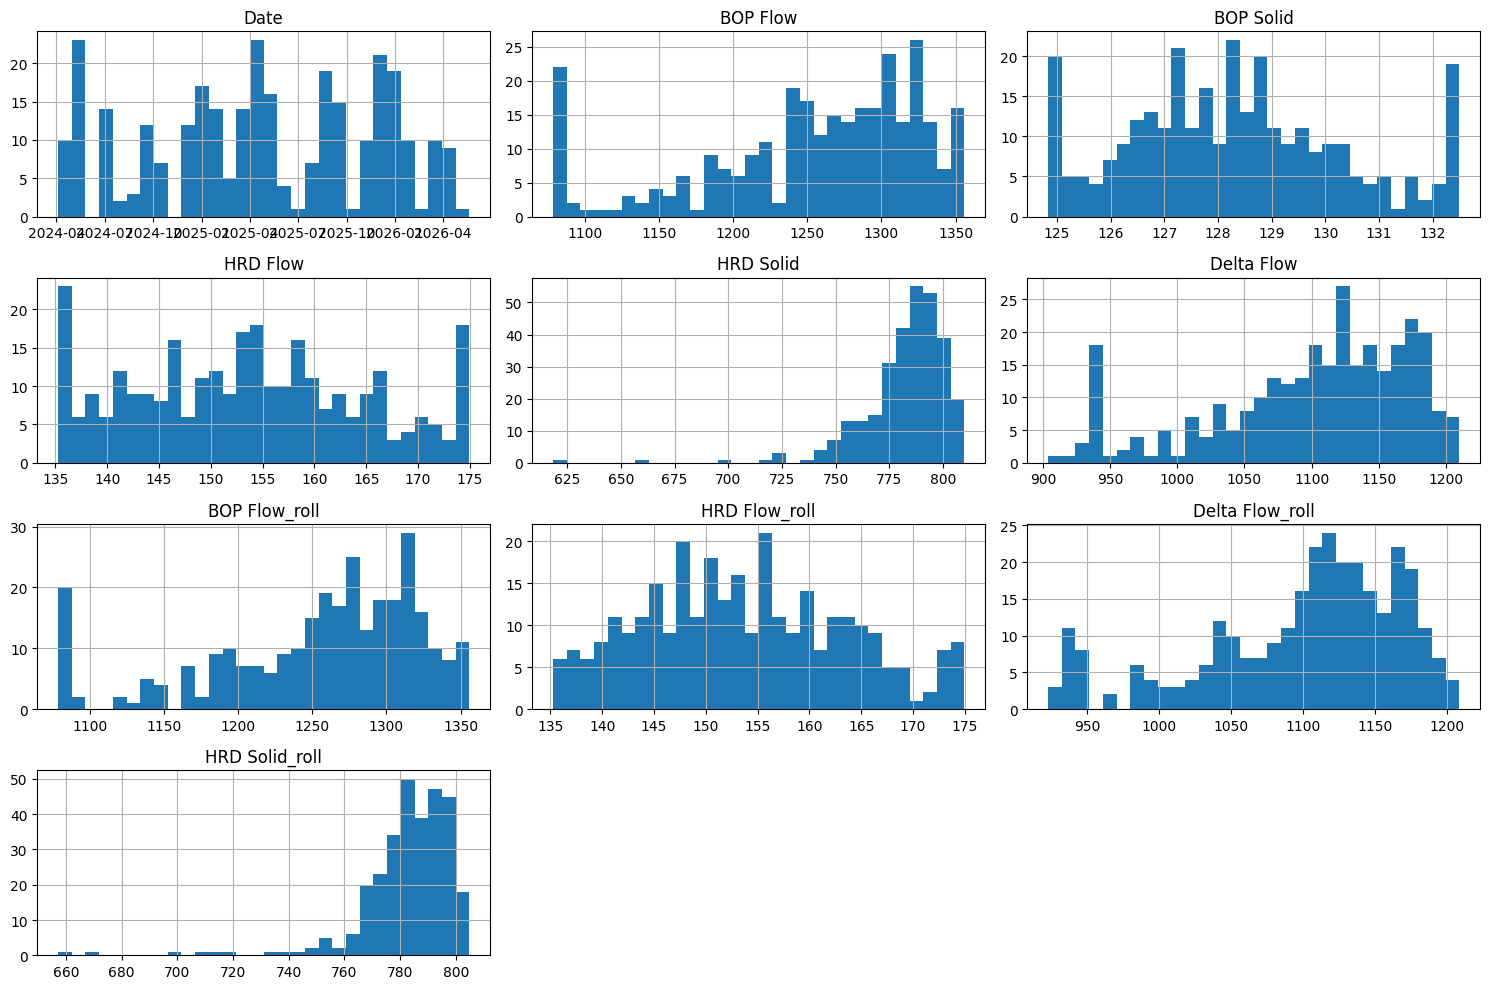

In [189]:
import matplotlib.pyplot as plt
df_hrd101.hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

In [190]:
df_hrd101.describe()

,Date,BOP Flow,BOP Solid,HRD Flow,HRD Solid,Delta Flow,BOP Flow_roll,HRD Flow_roll,Delta Flow_roll,HRD Solid_roll
count,300,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2025-04-24 15:40:48,1253.838582,128.315032,153.604917,782.347222,1100.233665,1253.930120,153.621745,1100.308375,782.388889
min,2024-04-04 00:00:00,1078.637139,124.833333,135.239665,618.333333,903.683735,1078.637139,135.239665,922.679368,657.166667
25%,2024-12-07 18:00:00,1214.181765,126.958333,144.819317,775.333333,1060.689871,1215.671478,146.293551,1058.564113,777.000000
50%,2025-04-21 12:00:00,1269.449481,128.333333,153.491987,787.000000,1116.033033,1270.504514,152.881703,1114.931989,784.916667
75%,2025-11-16 06:00:00,1310.044867,129.666667,161.675605,795.666667,1158.500494,1309.325714,160.562890,1152.475147,793.500000
max,2026-05-21 00:00:00,1355.866829,132.500000,174.953404,810.000000,1210.014396,1355.866829,174.953404,1208.730873,804.833333
std,NaN,75.440618,2.040683,11.301502,20.979080,73.138196,71.651569,9.794336,69.314428,17.876401


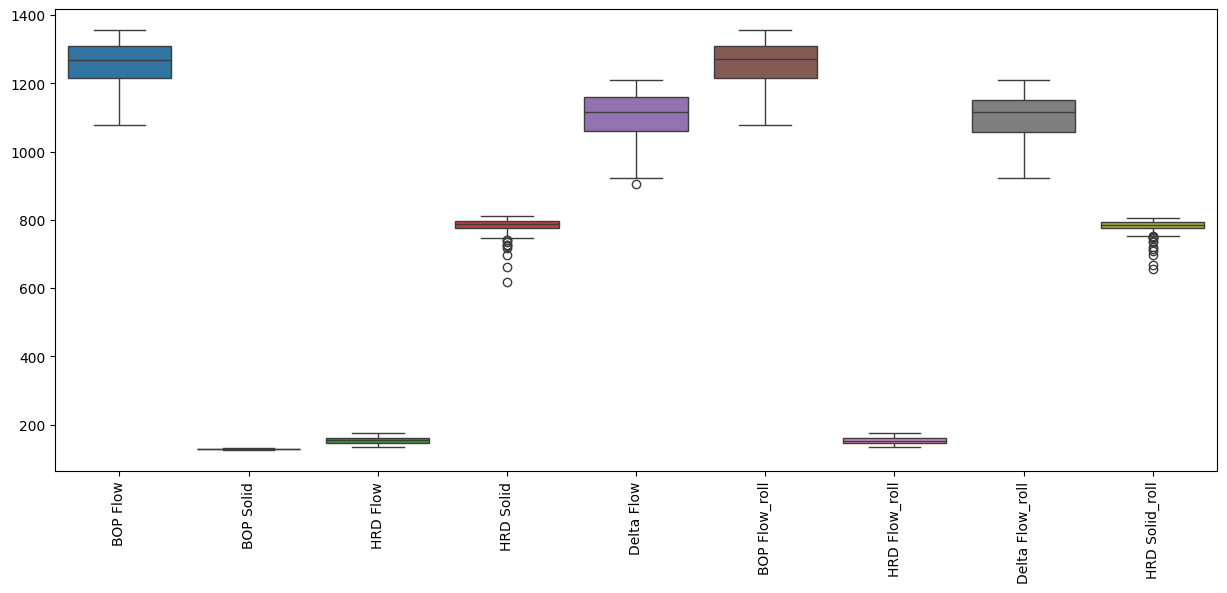

In [191]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
sns.boxplot(data=df_hrd101.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.show()

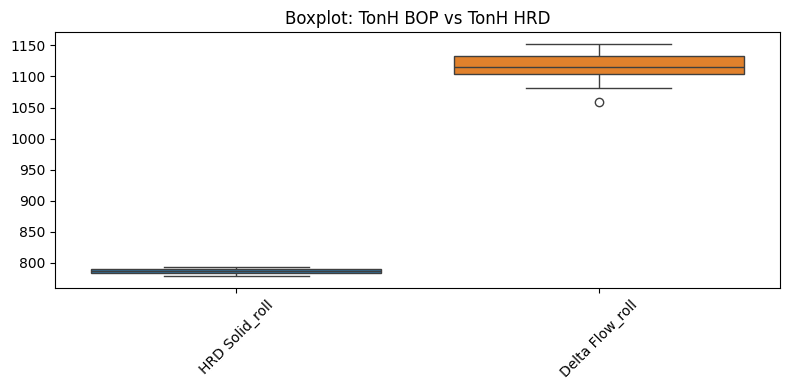

In [199]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only the required columns
cols = ['HRD Solid_roll', 'Delta Flow_roll']

plt.figure(figsize=(8,4))
sns.boxplot(data=df_hrd101[cols])

plt.title("Boxplot: TonH BOP vs TonH HRD")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Bivariant Analysis

In [193]:
df_hrd101 = df_hrd101[df_hrd101['HRD Solid_roll'] > 777].copy()

In [194]:
df_hrd101 = df_hrd101[df_hrd101['HRD Solid_roll'] <793].copy()

In [195]:
df_hrd101 = df_hrd101[df_hrd101['Delta Flow_roll'] > 1058.564113].copy()

In [196]:
df_hrd101 = df_hrd101[df_hrd101['Delta Flow_roll'] < 1152.475147].copy()

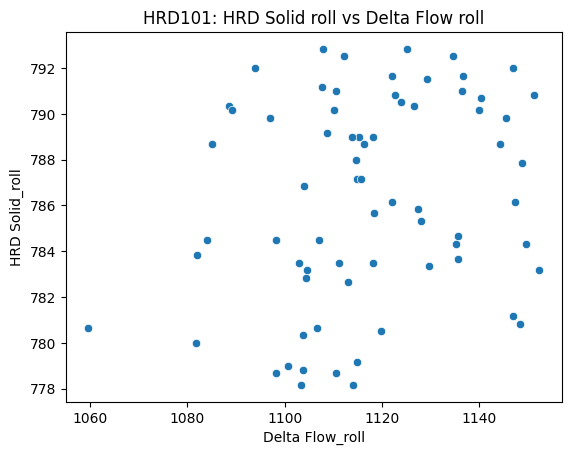

In [197]:
import matplotlib.pyplot as plt
import seaborn as sns

# HRD Solid vs Delta
plt.figure()
sns.scatterplot(data=df_hrd101, x='Delta Flow_roll', y='HRD Solid_roll')
plt.title('HRD101: HRD Solid roll vs Delta Flow roll')
plt.show()

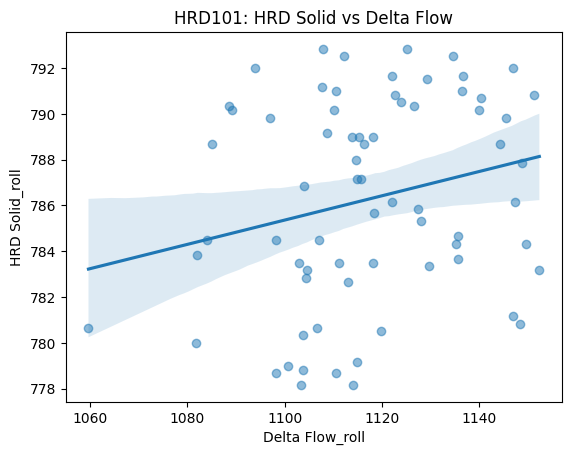

In [198]:
sns.regplot(
    data=df_hrd101,
    x='Delta Flow_roll',
    y='HRD Solid_roll',
    scatter_kws={'alpha':0.5}
)
plt.title('HRD101: HRD Solid vs Delta Flow')
plt.show()

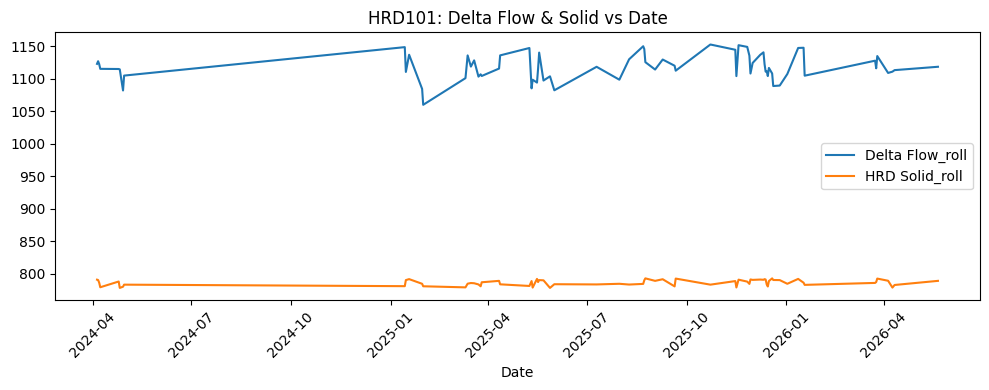

In [50]:
plt.figure(figsize=(10,4))

plt.plot(df_hrd101['Date'], df_hrd101['Delta Flow_roll'], label='Delta Flow_roll')
plt.plot(df_hrd101['Date'], df_hrd101['HRD Solid_roll'], label='HRD Solid_roll')

plt.title("HRD101: Delta Flow & Solid vs Date")
plt.xlabel("Date")
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

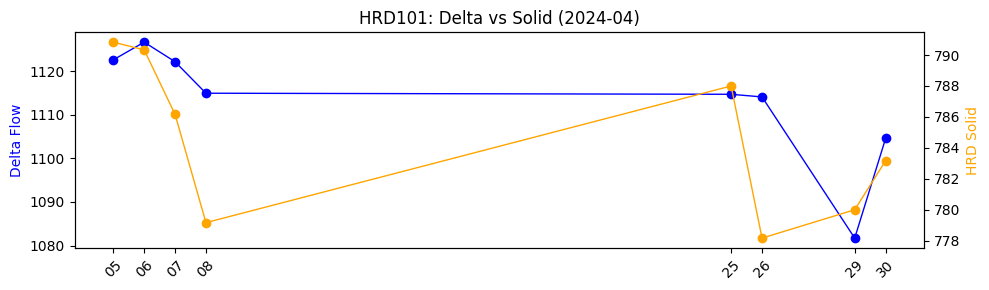

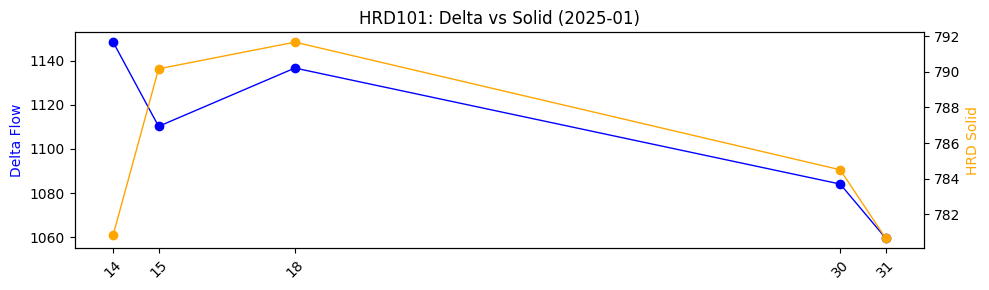

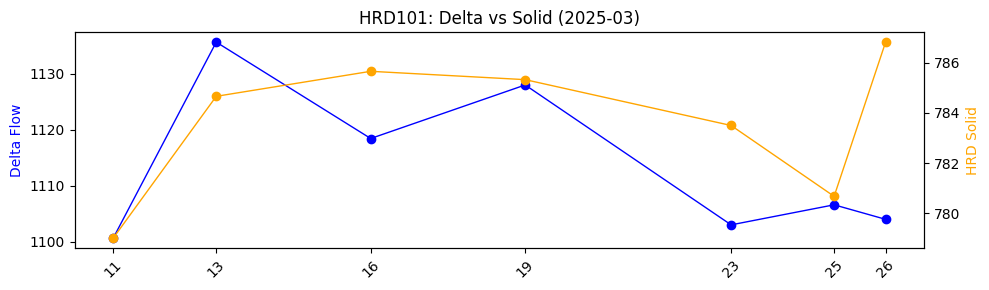

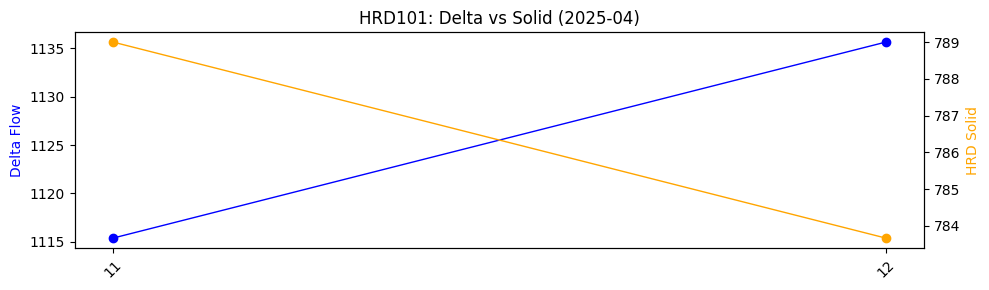

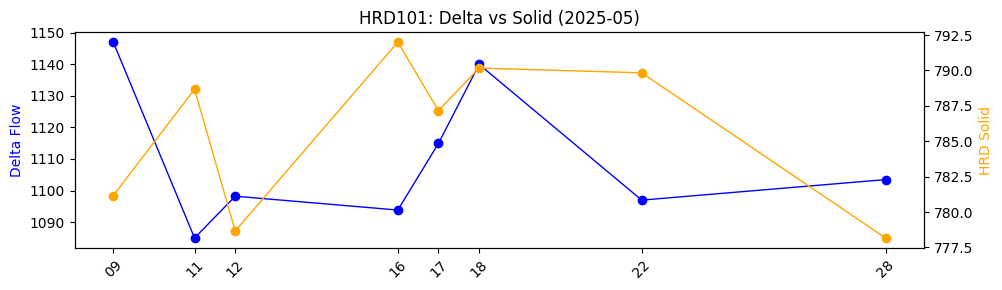

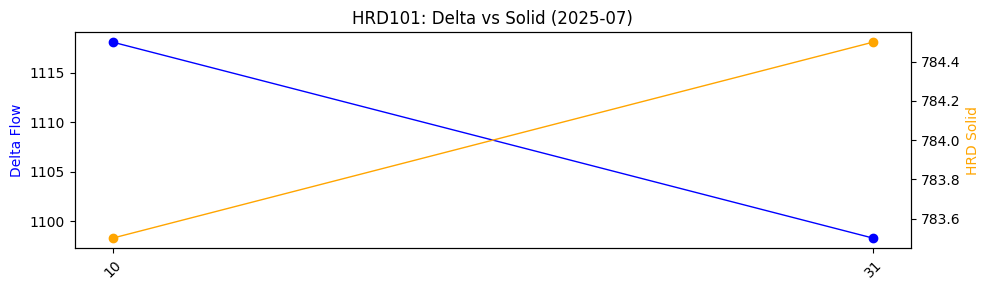

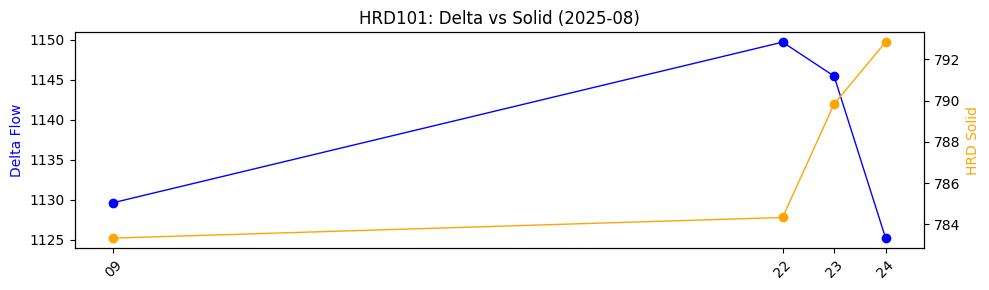

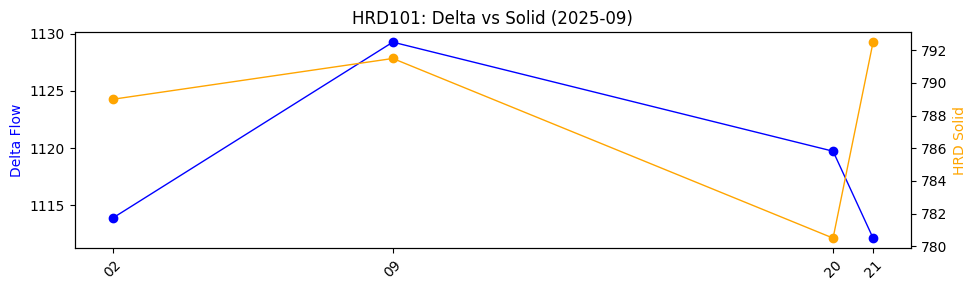

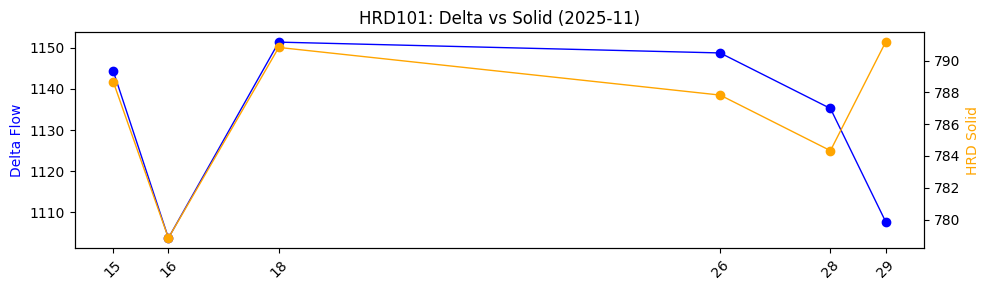

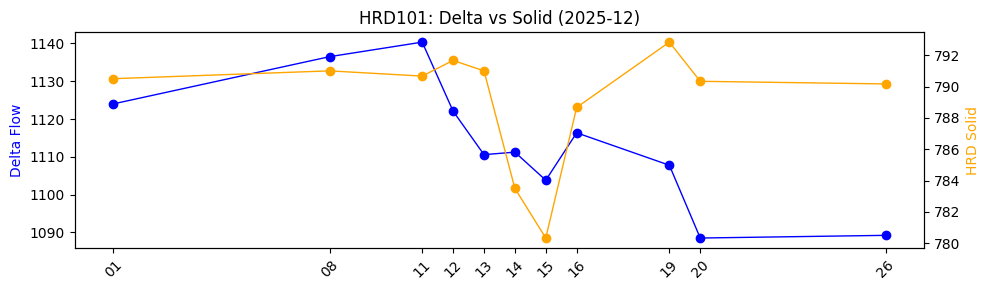

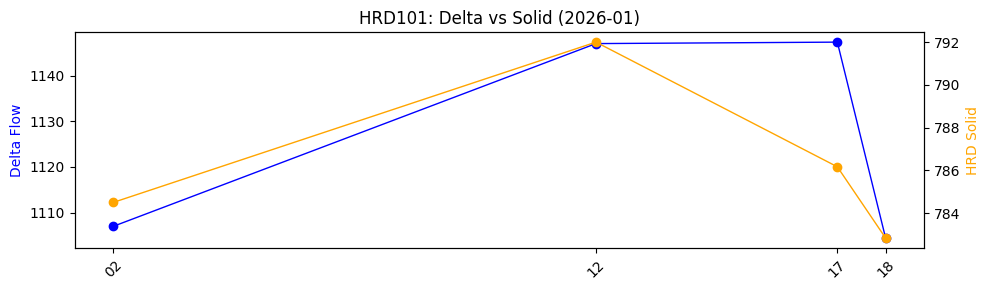

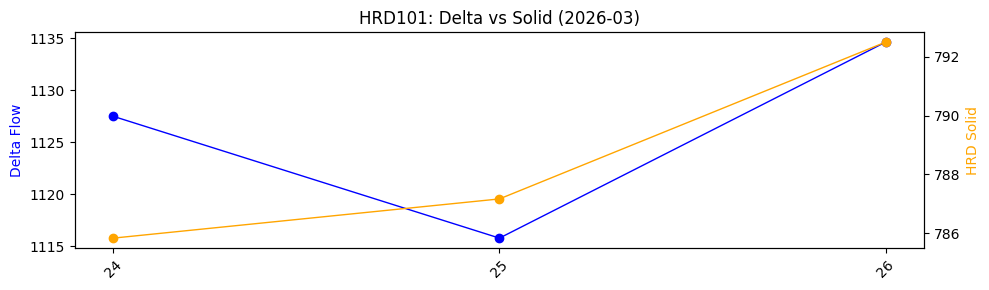

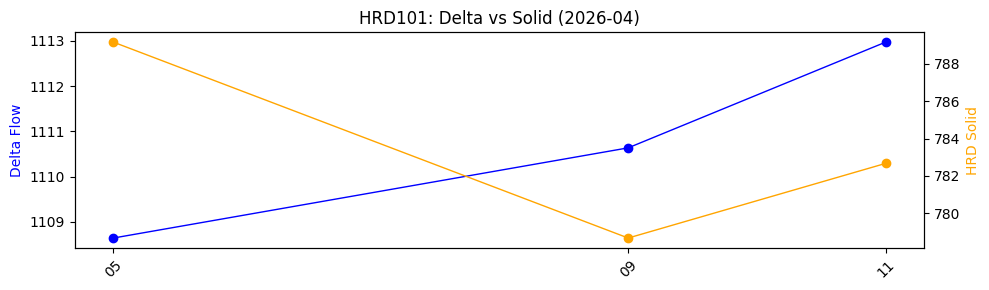

In [51]:
#HRD101
df_hrd101['YearMonth'] = df_hrd101['Date'].dt.to_period('M')

import matplotlib.pyplot as plt

for month, data in df_hrd101.groupby('YearMonth'):

    if data.shape[0] < 2:
        continue   # skip empty/small months

    fig, ax1 = plt.subplots(figsize=(10,3))

    # ✅ Delta Flow with markers
    ax1.plot(
        data['Date'],
        data['Delta Flow_roll'],
        color='blue',
        marker='o',        # 👈 important
        linewidth=1
    )
    ax1.set_ylabel("Delta Flow", color='blue')

    # ✅ HRD Solid with markers
    ax2 = ax1.twinx()
    ax2.plot(
        data['Date'],
        data['HRD Solid_roll'],
        color='orange',
        marker='o',        # 👈 important
        linewidth=1
    )
    ax2.set_ylabel("HRD Solid", color='orange')

    # ✅ Force daily ticks
    ax1.set_xticks(data['Date'])
    ax1.set_xticklabels(data['Date'].dt.strftime('%d'), rotation=45)

    plt.title(f"HRD101: Delta vs Solid ({month})")

    plt.tight_layout()
    plt.show()

In [52]:
corr_value = df_hrd101[['HRD Solid_roll', 'Delta Flow_roll']].corr()

print(corr_value)

                 HRD Solid_roll  Delta Flow_roll
HRD Solid_roll          1.00000          0.23607
Delta Flow_roll         0.23607          1.00000


## HRD102

In [54]:
df_hrd102.shape

(315, 11)

In [55]:
df_hrd102.info()

<class 'pandas.DataFrame'>
Index: 315 entries, 169 to 9
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             315 non-null    datetime64[us]
 1   BOP Name         315 non-null    str           
 2   BOP Flow         315 non-null    float64       
 3   BOP Solid        315 non-null    float64       
 4   HRD Flow         315 non-null    float64       
 5   HRD Solid        315 non-null    float64       
 6   Delta Flow       315 non-null    float64       
 7   BOP Flow_roll    315 non-null    float64       
 8   HRD Flow_roll    315 non-null    float64       
 9   Delta Flow_roll  315 non-null    float64       
 10  HRD Solid_roll   315 non-null    float64       
dtypes: datetime64[us](1), float64(9), str(1)
memory usage: 29.5 KB


In [56]:
df_hrd102.isnull().sum()

Date               0
BOP Name           0
BOP Flow           0
BOP Solid          0
HRD Flow           0
HRD Solid          0
Delta Flow         0
BOP Flow_roll      0
HRD Flow_roll      0
Delta Flow_roll    0
HRD Solid_roll     0
dtype: int64

### Univariant Analysis

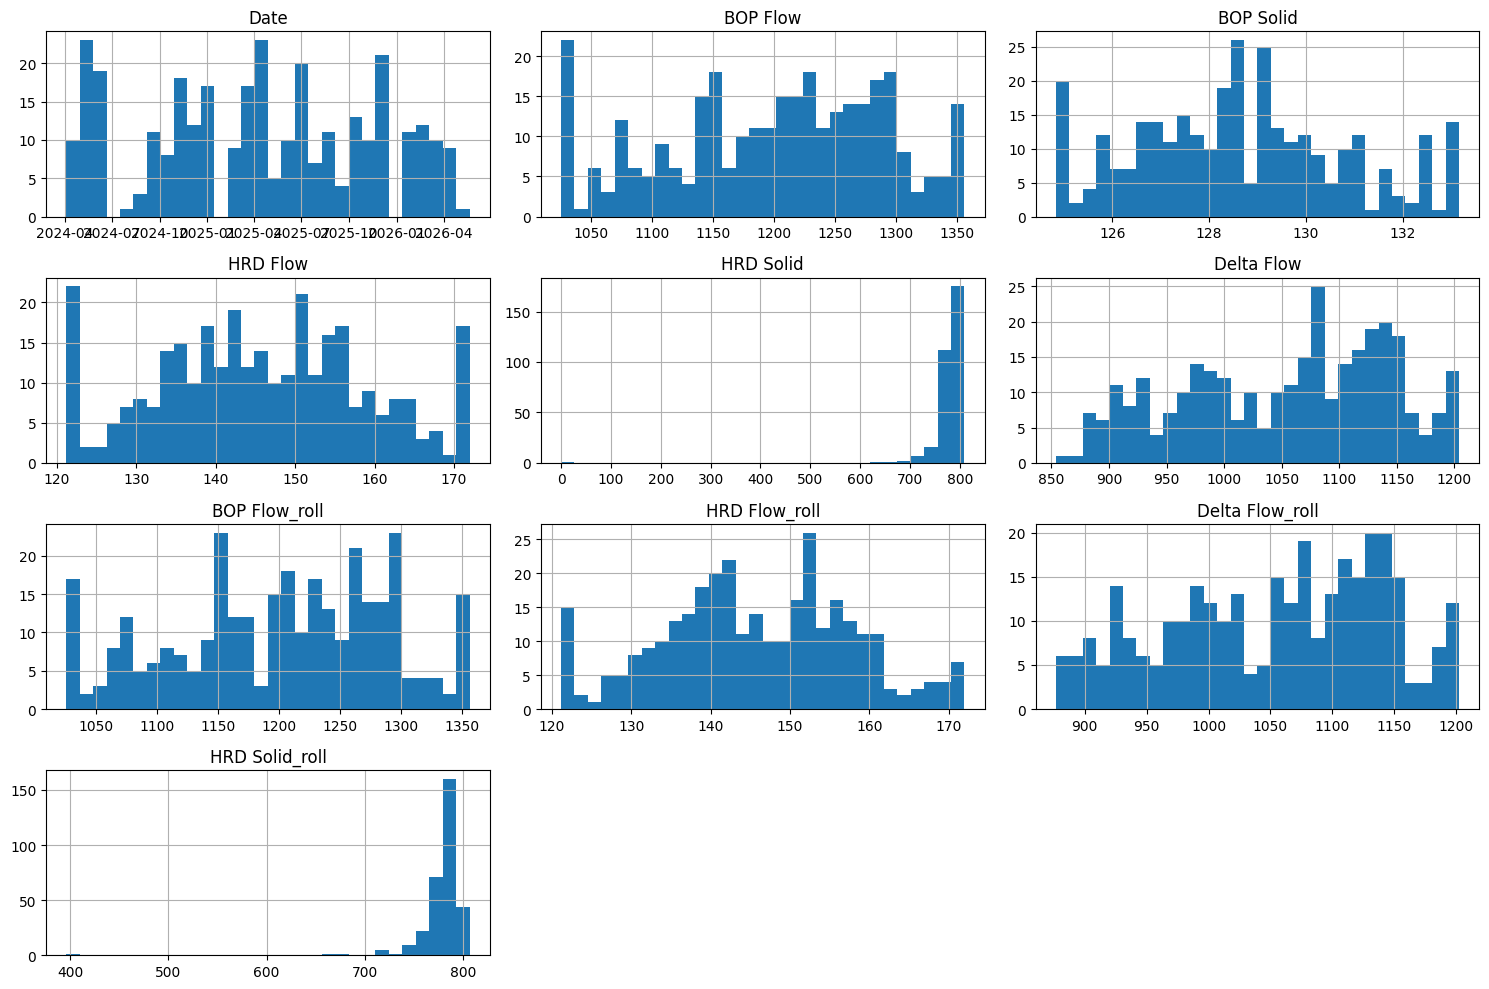

In [200]:
import matplotlib.pyplot as plt
df_hrd102.hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

In [201]:
df_hrd102.describe()

,Date,BOP Flow,BOP Solid,HRD Flow,HRD Solid,Delta Flow,BOP Flow_roll,HRD Flow_roll,Delta Flow_roll,HRD Solid_roll
count,315,315.000000,315.000000,315.000000,315.000000,315.000000,315.000000,315.000000,315.000000,315.000000
mean,2025-04-12 07:14:17.142857,1199.187523,128.644624,145.824891,777.628307,1053.362632,1199.232468,145.786344,1053.446124,778.856349
min,2024-04-04 00:00:00,1025.732764,124.833333,121.169226,0.000000,853.768160,1025.732764,121.169226,876.643500,396.000000
25%,2024-11-05 12:00:00,1137.891495,127.000000,136.080689,774.500000,981.695182,1140.970033,137.908258,987.076037,775.437500
50%,2025-04-14 00:00:00,1211.989187,128.666667,145.944993,783.666667,1068.353610,1206.036448,145.770265,1066.548936,783.333333
75%,2025-10-16 12:00:00,1269.890739,130.000000,155.058080,792.166667,1127.834460,1268.955110,154.282059,1127.027632,789.666667
max,2026-05-21 00:00:00,1355.866829,133.166667,171.964604,809.000000,1204.287903,1355.866829,171.964604,1202.466659,806.833333
std,NaN,90.146045,2.178920,13.301902,48.852149,89.208824,87.634859,11.941202,86.749718,27.575405


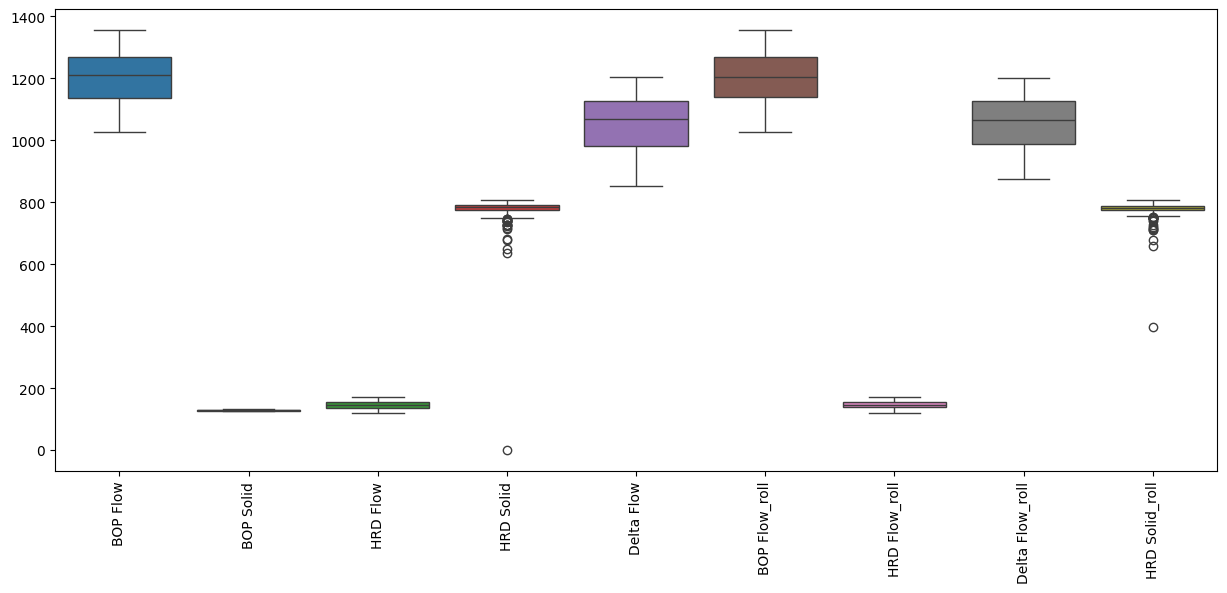

In [202]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
sns.boxplot(data=df_hrd102.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.show()

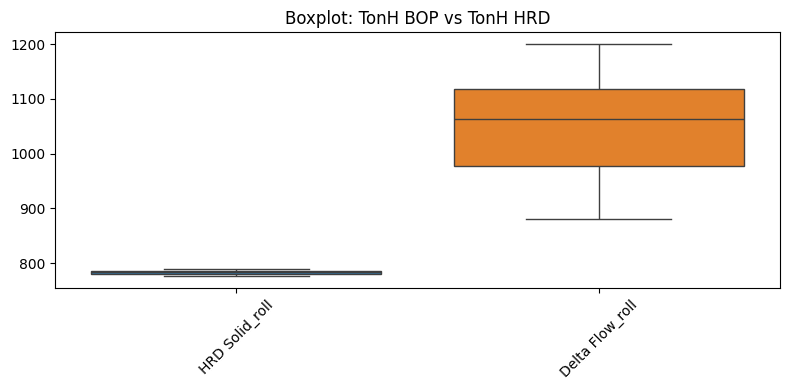

In [208]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only the required columns
cols = ['HRD Solid_roll', 'Delta Flow_roll']

plt.figure(figsize=(8,4))
sns.boxplot(data=df_hrd102[cols])

plt.title("Boxplot: TonH BOP vs TonH HRD")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Bivariant Analysis

In [204]:
df_hrd102 = df_hrd102[df_hrd102['HRD Solid_roll'] > 775.437500].copy()

In [205]:
df_hrd102 = df_hrd102[df_hrd102['HRD Solid_roll'] <789.666667].copy()

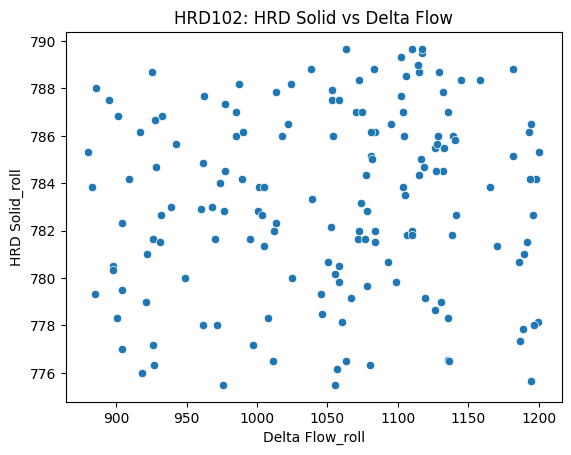

In [206]:
import matplotlib.pyplot as plt
import seaborn as sns

# HRD Solid vs Delta
plt.figure()
sns.scatterplot(data=df_hrd102, x='Delta Flow_roll', y='HRD Solid_roll')
plt.title('HRD102: HRD Solid vs Delta Flow')
plt.show()

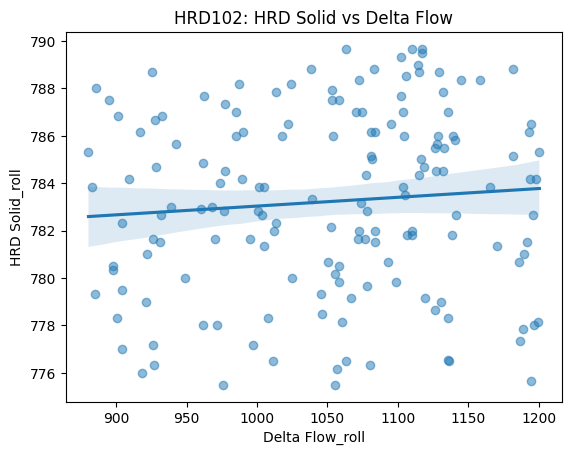

In [209]:
sns.regplot(
    data=df_hrd102,
    x='Delta Flow_roll',
    y='HRD Solid_roll',
    scatter_kws={'alpha':0.5}
)
plt.title('HRD102: HRD Solid vs Delta Flow')
plt.show()

In [138]:
corr_value = df_hrd102[['HRD Solid_roll', 'Delta Flow_roll']].corr()

print(corr_value)

                 HRD Solid_roll  Delta Flow_roll
HRD Solid_roll         1.000000         0.085906
Delta Flow_roll        0.085906         1.000000


In [64]:
df_hrd102 = df_hrd102[df_hrd102['HRD Solid_roll'] > 0]

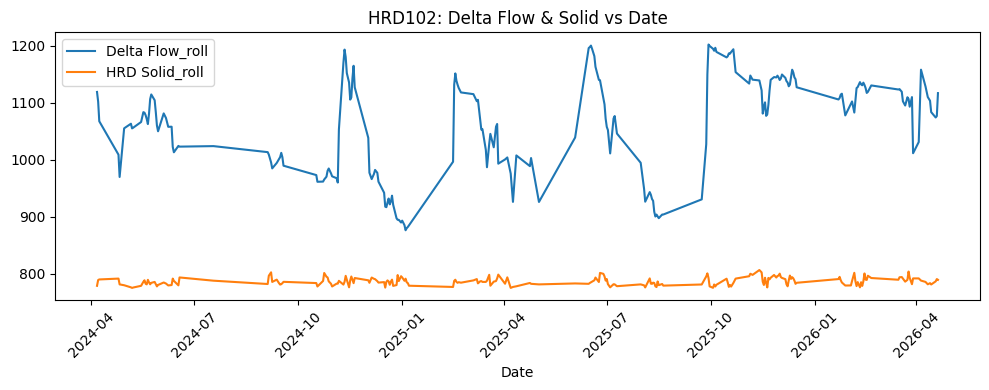

In [65]:
plt.figure(figsize=(10,4))

plt.plot(df_hrd102['Date'], df_hrd102['Delta Flow_roll'], label='Delta Flow_roll')
plt.plot(df_hrd102['Date'], df_hrd102['HRD Solid_roll'], label='HRD Solid_roll')

plt.title("HRD102: Delta Flow & Solid vs Date")
plt.xlabel("Date")
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

## HRD201

In [816]:
df_hrd201.shape

(272, 11)

In [817]:
df_hrd201.info()

<class 'pandas.DataFrame'>
Index: 272 entries, 149 to 147
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             272 non-null    datetime64[us]
 1   BOP Name         272 non-null    str           
 2   BOP Flow         272 non-null    float64       
 3   BOP Solid        272 non-null    float64       
 4   HRD Flow         272 non-null    float64       
 5   HRD Solid        272 non-null    float64       
 6   Delta Flow       272 non-null    float64       
 7   BOP Flow_roll    272 non-null    float64       
 8   HRD Flow_roll    272 non-null    float64       
 9   Delta Flow_roll  272 non-null    float64       
 10  HRD Solid_roll   272 non-null    float64       
dtypes: datetime64[us](1), float64(9), str(1)
memory usage: 25.5 KB


In [818]:
df_hrd201.isnull().sum()

Date               0
BOP Name           0
BOP Flow           0
BOP Solid          0
HRD Flow           0
HRD Solid          0
Delta Flow         0
BOP Flow_roll      0
HRD Flow_roll      0
Delta Flow_roll    0
HRD Solid_roll     0
dtype: int64

### Univariant Analysis

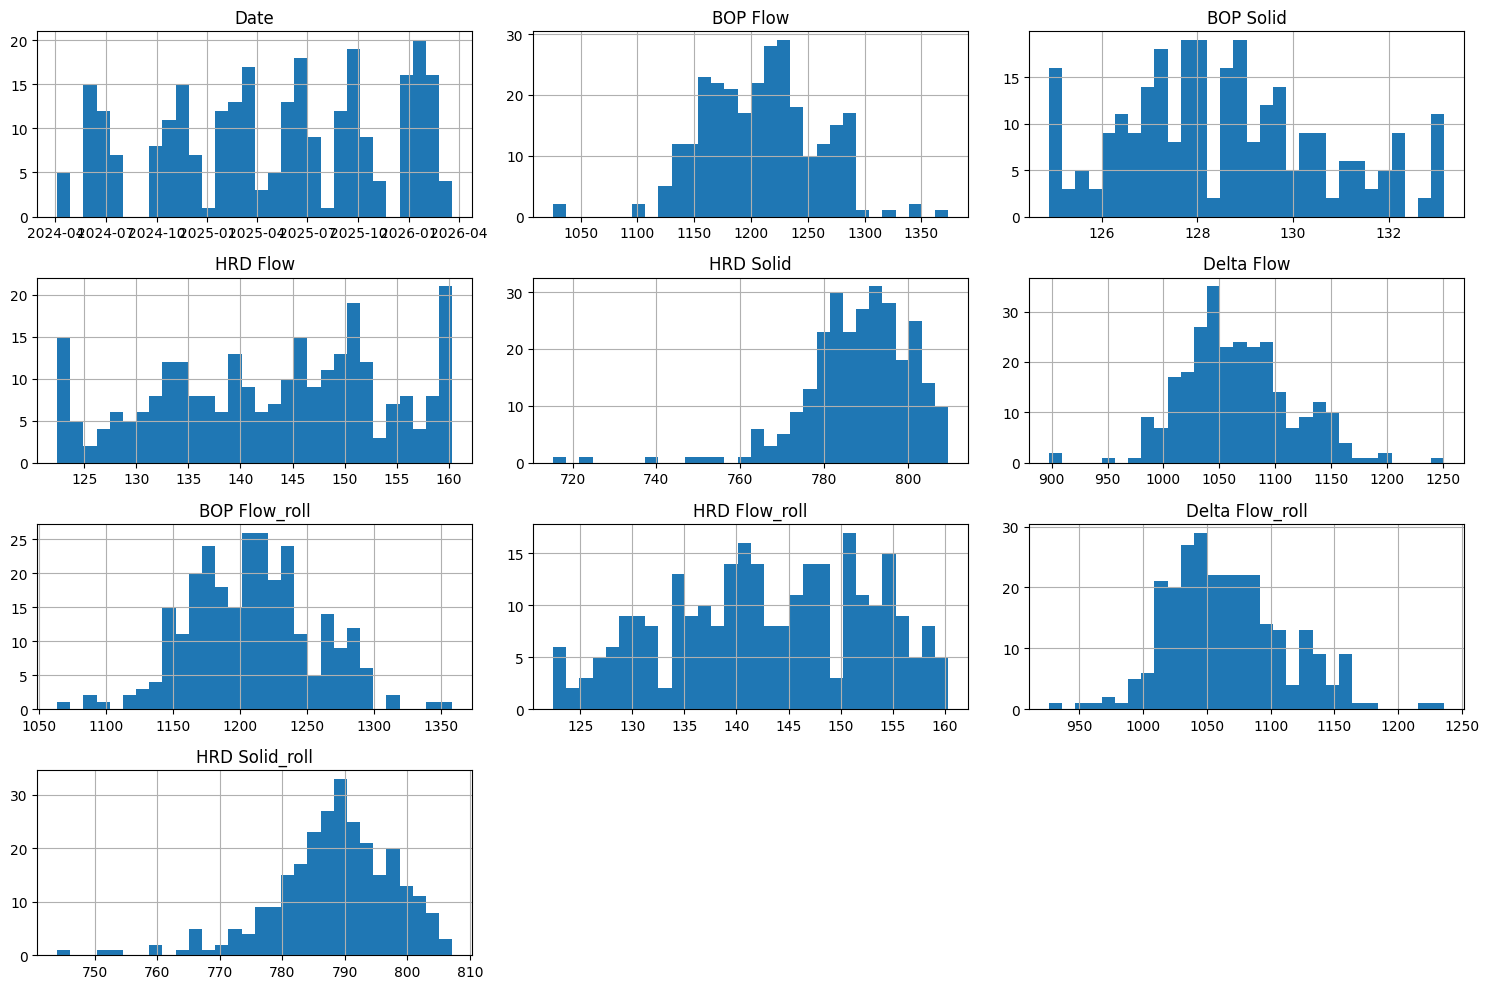

In [819]:
import matplotlib.pyplot as plt
df_hrd201.hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

In [820]:
df_hrd201.describe()

,Date,BOP Flow,BOP Solid,HRD Flow,HRD Solid,Delta Flow,BOP Flow_roll,HRD Flow_roll,Delta Flow_roll,HRD Solid_roll
count,272,272.000000,272.000000,272.000000,272.000000,272.000000,272.000000,272.000000,272.000000,272.000000
mean,2025-05-02 07:35:17.647058,1208.953295,128.562304,143.030717,788.319547,1065.922579,1208.949023,142.978734,1065.970289,788.283395
min,2024-04-04 00:00:00,1025.732764,124.893333,122.372602,715.333333,897.685813,1063.182459,122.372602,926.240354,744.000000
25%,2024-11-15 18:00:00,1172.847680,127.000000,134.479930,781.666667,1032.790274,1175.324081,135.625016,1034.470037,783.458333
50%,2025-05-21 00:00:00,1210.824336,128.416667,144.374293,790.000000,1058.585760,1208.283445,143.051854,1060.538964,788.916667
75%,2025-10-05 06:00:00,1239.935715,129.833333,151.221899,797.000000,1093.576881,1237.329666,150.985159,1091.939993,794.833333
max,2026-03-20 00:00:00,1373.730499,133.166667,160.354345,809.666667,1251.357897,1358.523618,160.354345,1236.151016,807.166667
std,NaN,50.129100,2.120550,10.876152,13.016994,49.390366,46.611426,9.601318,46.409992,9.727265


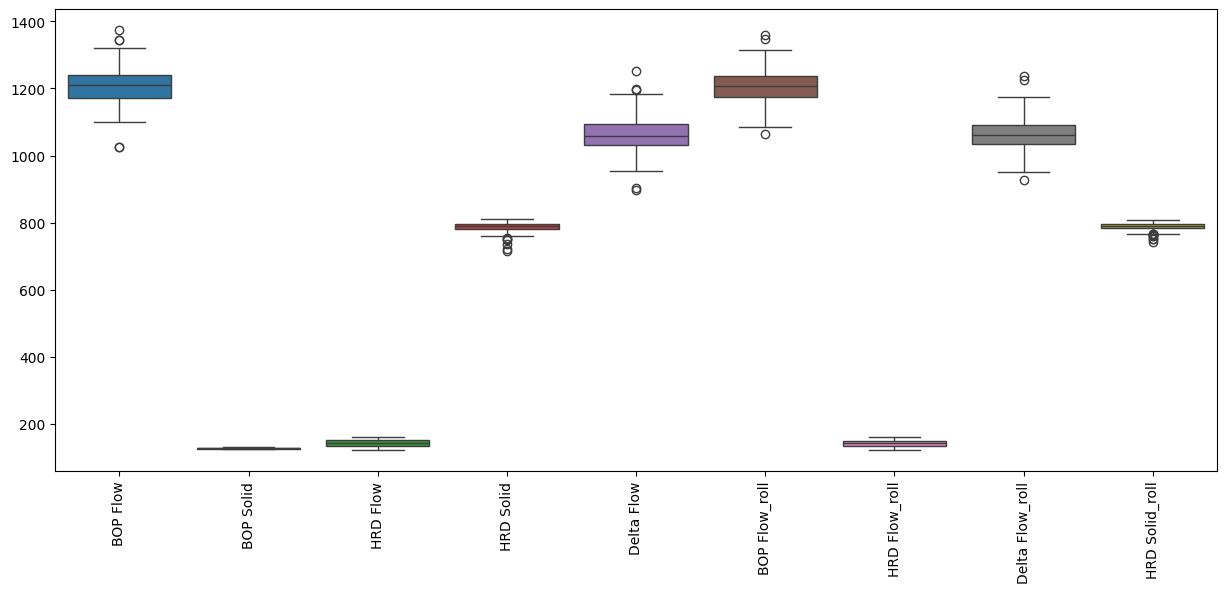

In [210]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
sns.boxplot(data=df_hrd201.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.show()

## Bivariant Analysis

In [211]:
df_hrd201 = df_hrd201[df_hrd201['HRD Solid_roll'] > 783.458333]

In [212]:
df_hrd201 = df_hrd201[df_hrd201['Delta Flow_roll'] > 1034.470037]

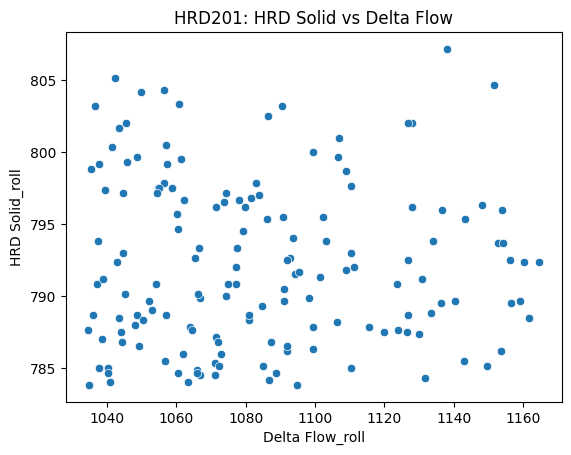

In [213]:
import matplotlib.pyplot as plt
import seaborn as sns

# HRD Solid vs Delta
plt.figure()
sns.scatterplot(data=df_hrd201, x='Delta Flow_roll', y='HRD Solid_roll')
plt.title('HRD201: HRD Solid vs Delta Flow')
plt.show()

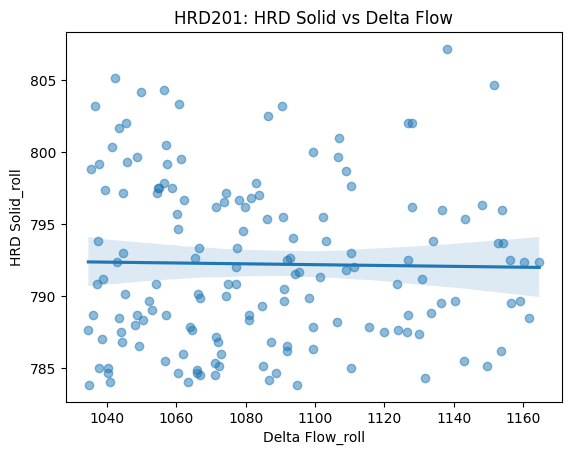

In [215]:
sns.regplot(
    data=df_hrd201,
    x='Delta Flow_roll',
    y='HRD Solid_roll',
    scatter_kws={'alpha':0.5}
)
plt.title('HRD201: HRD Solid vs Delta Flow')
plt.show()

In [826]:
corr_value = df_hrd201[['HRD Solid_roll', 'Delta Flow_roll']].corr()

print(corr_value)

                 HRD Solid_roll  Delta Flow_roll
HRD Solid_roll         1.000000        -0.018491
Delta Flow_roll       -0.018491         1.000000


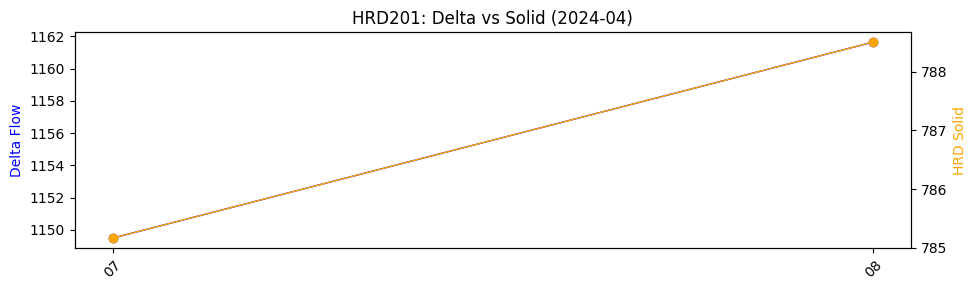

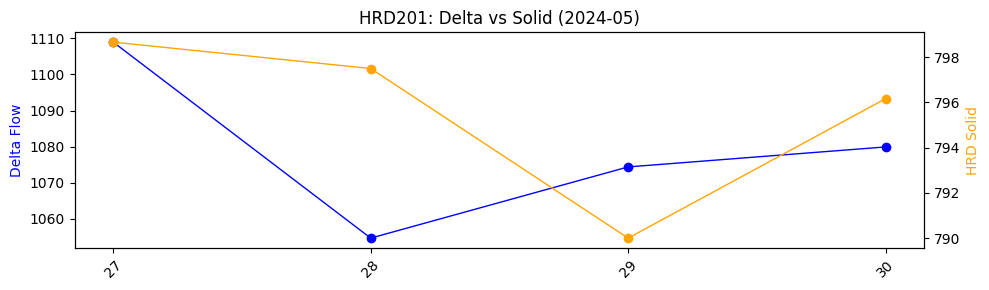

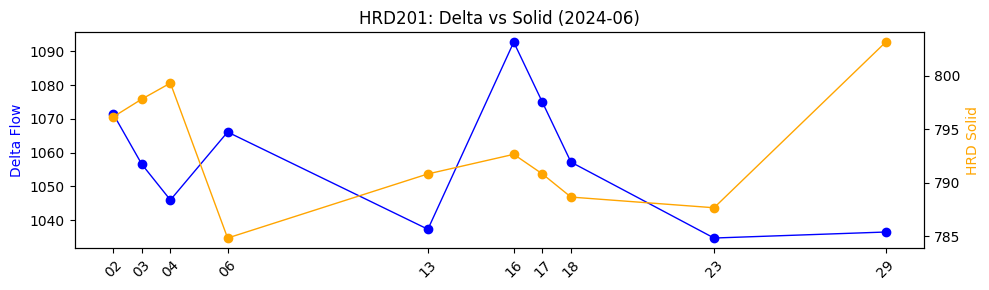

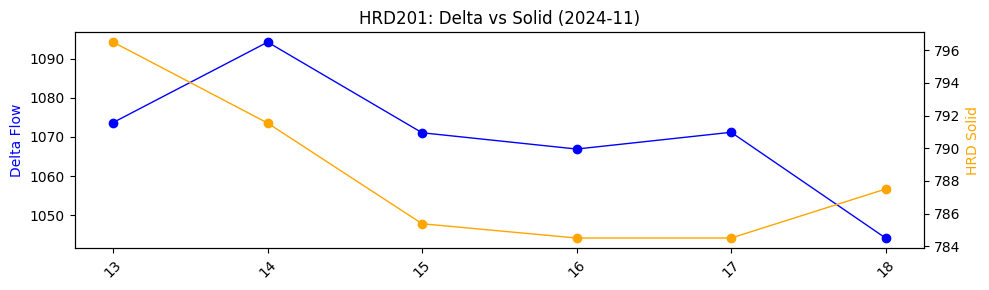

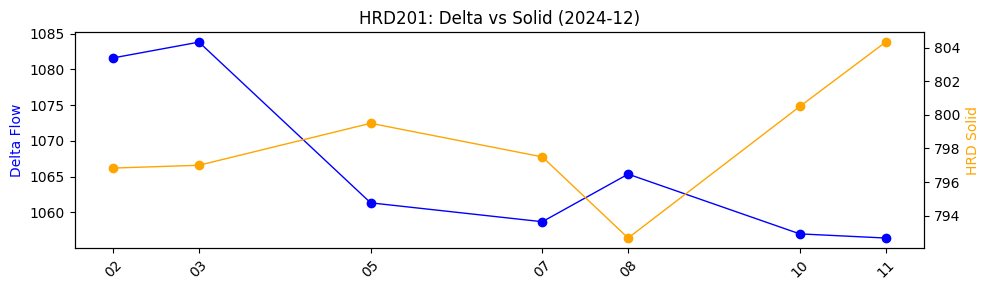

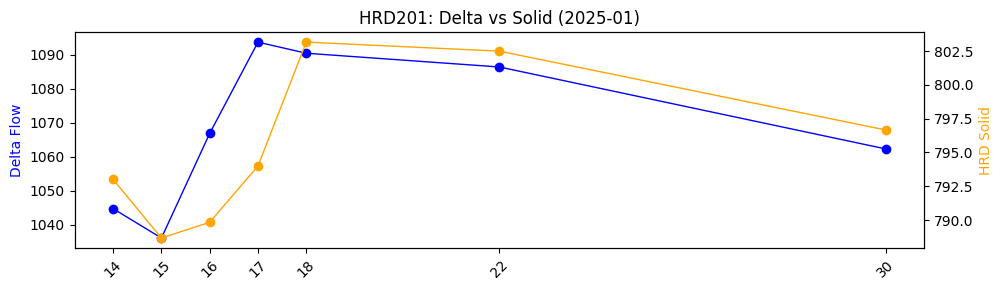

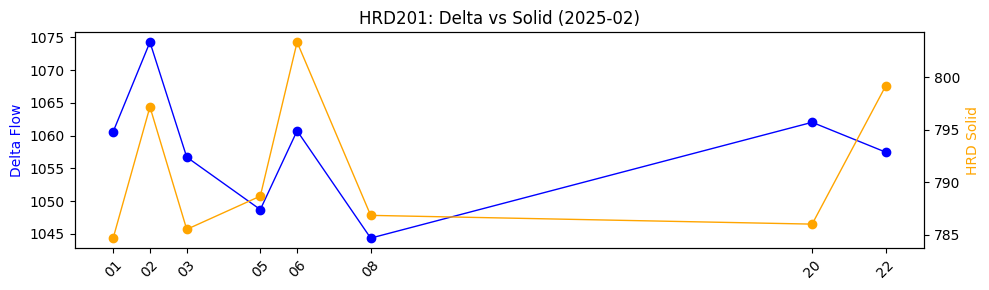

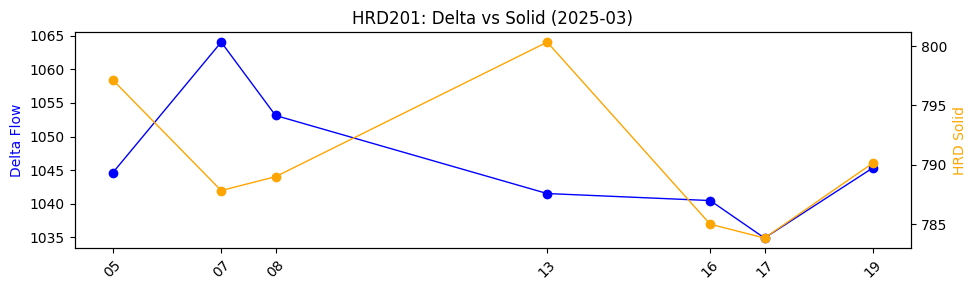

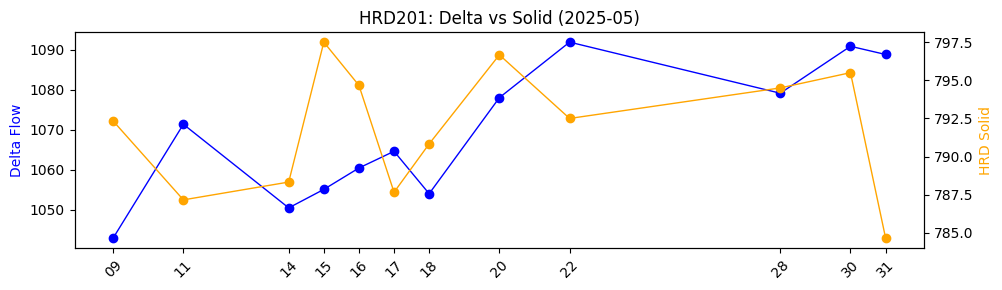

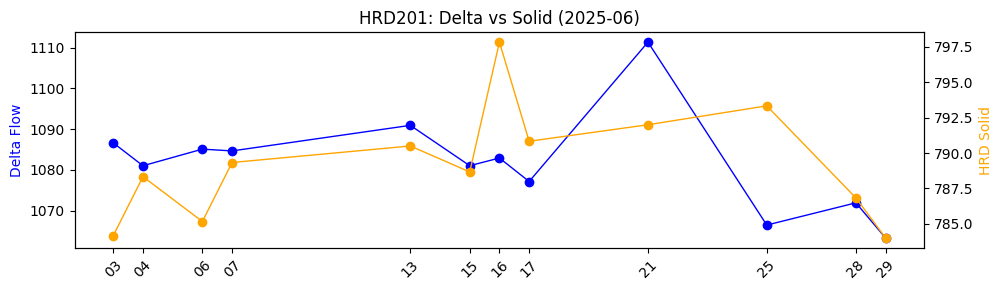

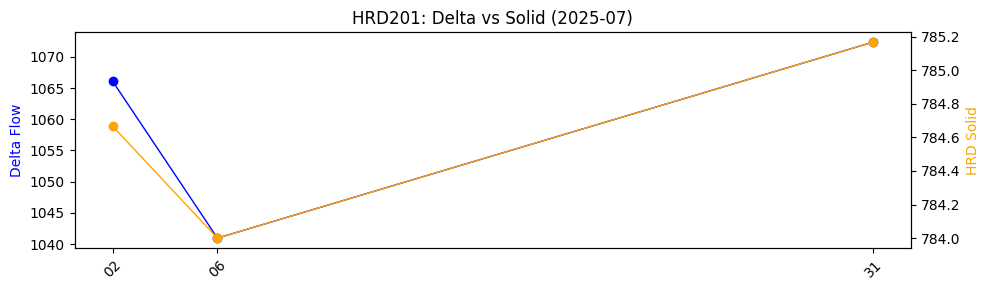

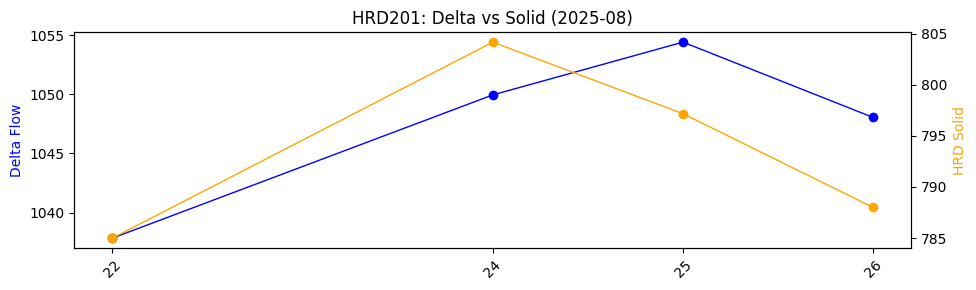

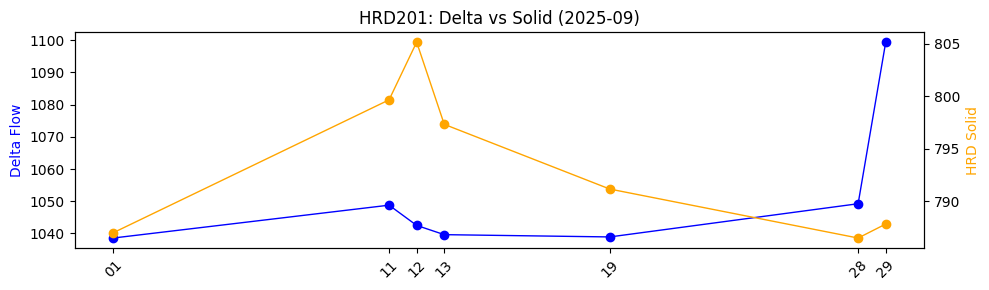

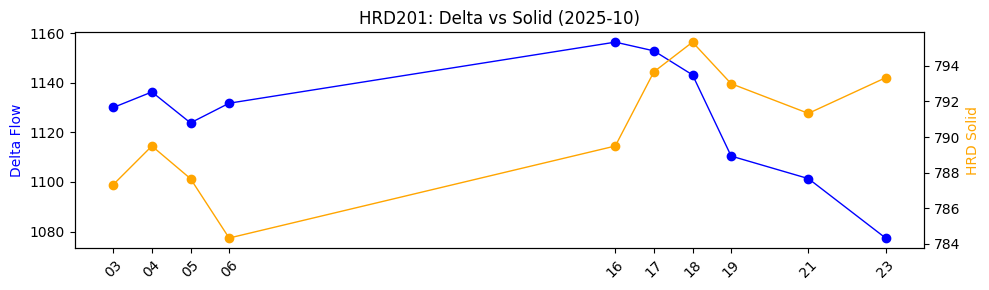

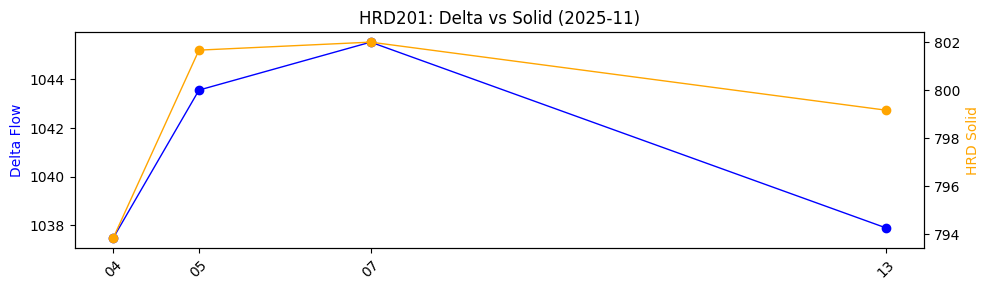

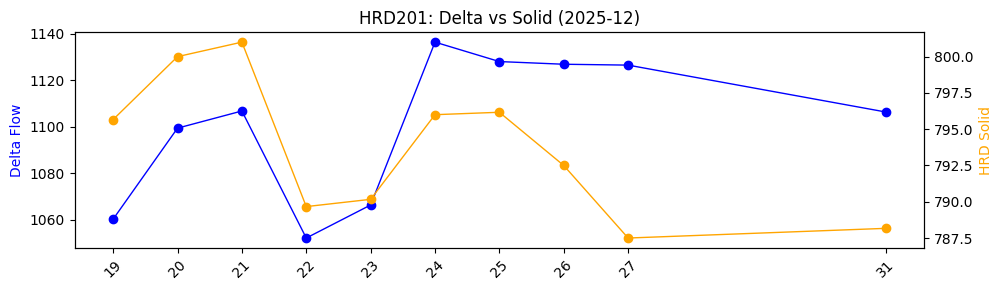

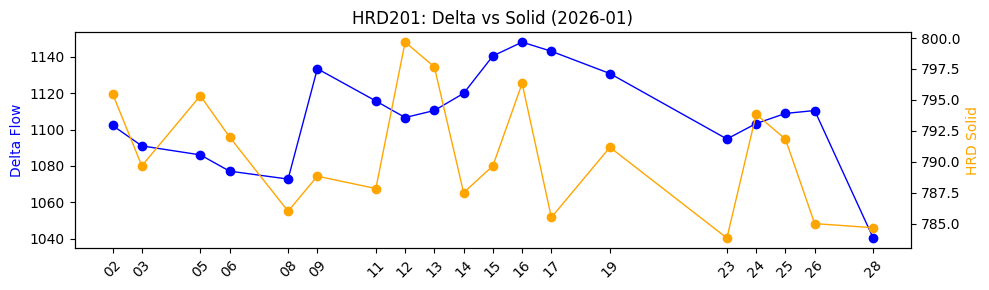

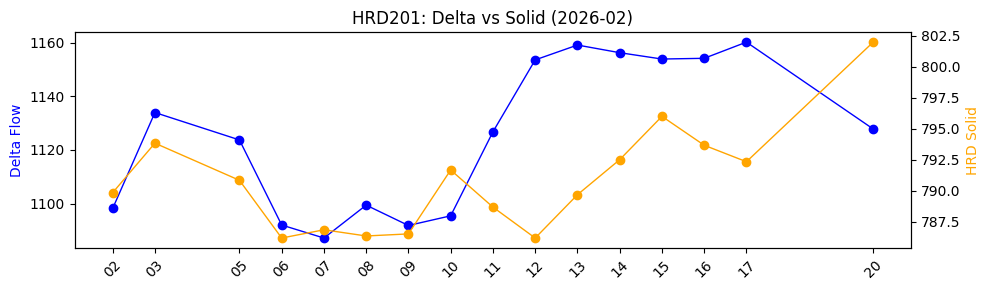

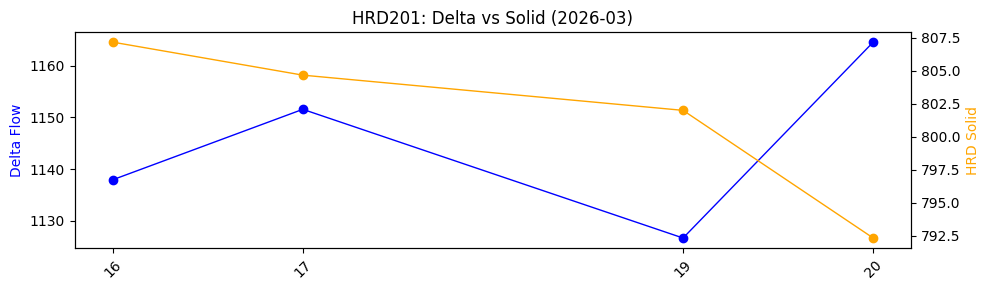

In [827]:
#HRD201
df_hrd201['YearMonth'] = df_hrd201['Date'].dt.to_period('M')

import matplotlib.pyplot as plt

for month, data in df_hrd201.groupby('YearMonth'):

    if data.shape[0] < 2:
        continue   # skip empty/small months

    fig, ax1 = plt.subplots(figsize=(10,3))

    # ✅ Delta Flow with markers
    ax1.plot(
        data['Date'],
        data['Delta Flow_roll'],
        color='blue',
        marker='o',        # 👈 important
        linewidth=1
    )
    ax1.set_ylabel("Delta Flow", color='blue')

    # ✅ HRD Solid with markers
    ax2 = ax1.twinx()
    ax2.plot(
        data['Date'],
        data['HRD Solid_roll'],
        color='orange',
        marker='o',        # 👈 important
        linewidth=1
    )
    ax2.set_ylabel("HRD Solid", color='orange')

    # ✅ Force daily ticks
    ax1.set_xticks(data['Date'])
    ax1.set_xticklabels(data['Date'].dt.strftime('%d'), rotation=45)

    plt.title(f"HRD201: Delta vs Solid ({month})")

    plt.tight_layout()
    plt.show()

### HRD301

In [828]:
df_hrd301.shape

(384, 11)

In [829]:
df_hrd301.info()

<class 'pandas.DataFrame'>
Index: 384 entries, 222 to 9
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             384 non-null    datetime64[us]
 1   BOP Name         384 non-null    str           
 2   BOP Flow         384 non-null    float64       
 3   BOP Solid        384 non-null    float64       
 4   HRD Flow         384 non-null    float64       
 5   HRD Solid        384 non-null    float64       
 6   Delta Flow       384 non-null    float64       
 7   BOP Flow_roll    384 non-null    float64       
 8   HRD Flow_roll    384 non-null    float64       
 9   Delta Flow_roll  384 non-null    float64       
 10  HRD Solid_roll   384 non-null    float64       
dtypes: datetime64[us](1), float64(9), str(1)
memory usage: 36.0 KB


In [830]:
df_hrd301.isnull().sum()

Date               0
BOP Name           0
BOP Flow           0
BOP Solid          0
HRD Flow           0
HRD Solid          0
Delta Flow         0
BOP Flow_roll      0
HRD Flow_roll      0
Delta Flow_roll    0
HRD Solid_roll     0
dtype: int64

## Univariant Analysis

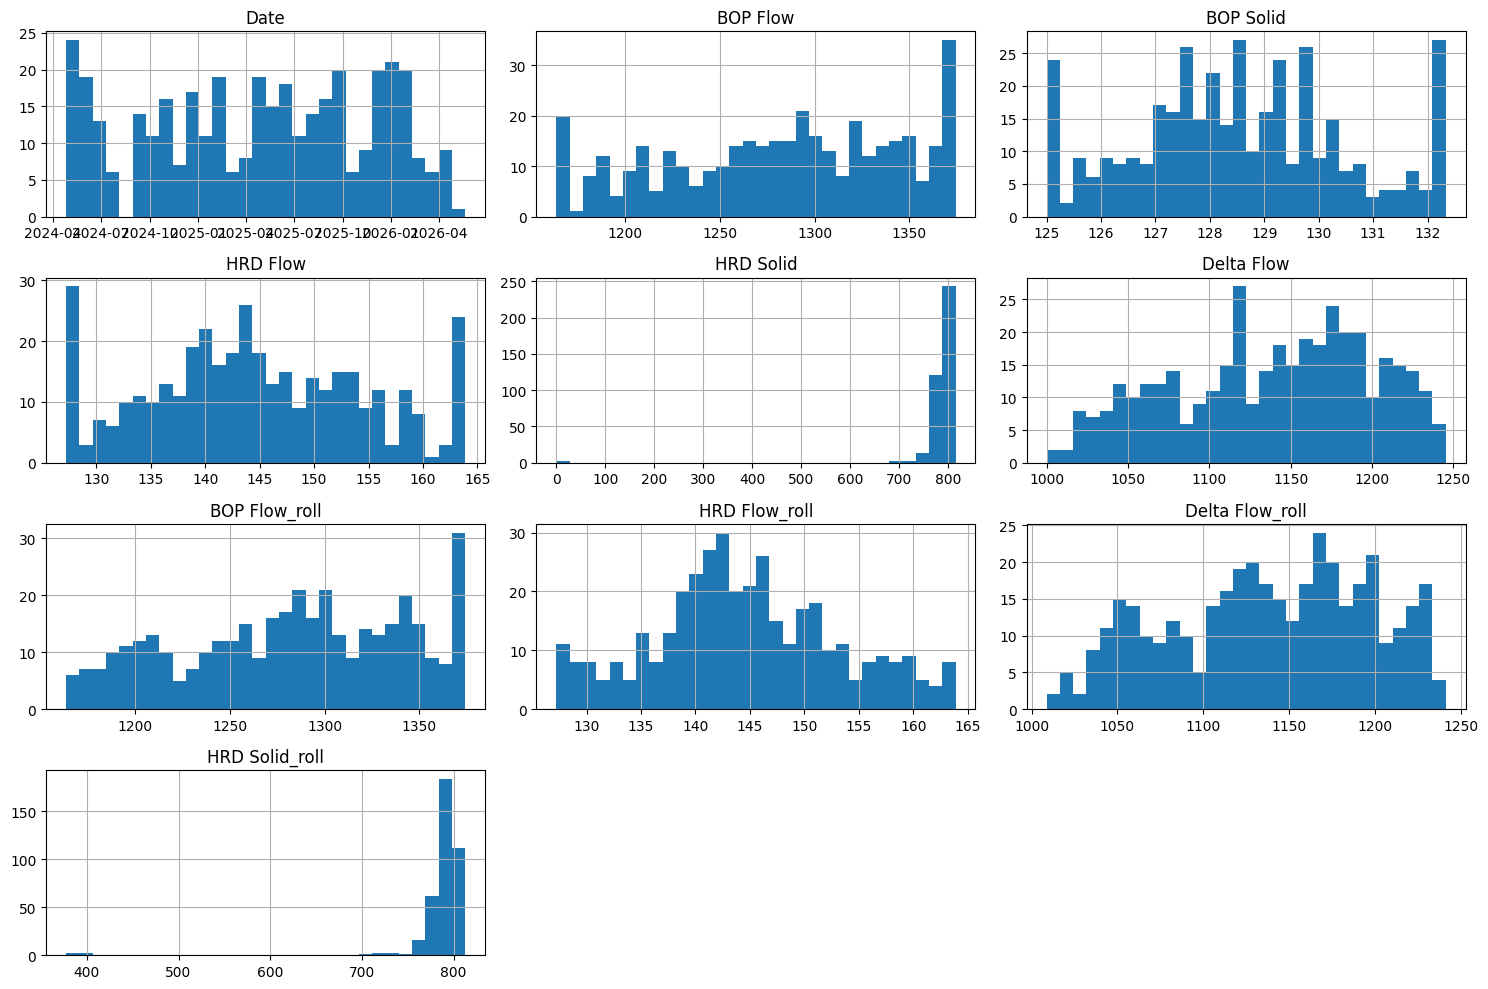

In [216]:
import matplotlib.pyplot as plt
df_hrd301.hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

In [217]:
df_hrd301.describe()

,Date,BOP Flow,BOP Solid,HRD Flow,HRD Solid,Delta Flow,BOP Flow_roll,HRD Flow_roll,Delta Flow_roll,HRD Solid_roll
count,384,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000
mean,2025-04-25 18:48:45,1283.025029,128.562903,144.647635,786.852648,1138.377394,1283.056058,144.629156,1138.426902,786.838759
min,2024-04-26 00:00:00,1163.546614,125.000000,127.219727,0.000000,999.853120,1163.546614,127.219727,1008.724439,377.250000
25%,2024-11-05 18:00:00,1236.929357,127.333333,138.051306,784.250000,1093.566707,1239.579213,139.280557,1092.951518,785.458333
50%,2025-05-11 12:00:00,1289.080493,128.500000,143.889002,793.333333,1146.103640,1287.646402,143.971192,1142.336666,793.500000
75%,2025-10-18 06:00:00,1334.548211,129.833333,152.099491,802.062500,1186.956479,1333.761202,150.340885,1183.207561,799.500000
max,2026-05-21 00:00:00,1374.306078,132.333333,163.885327,815.666667,1245.312312,1374.306078,163.885327,1240.991773,812.833333
std,NaN,61.407212,1.956841,10.000171,59.436403,60.800118,58.495053,8.588203,57.991748,43.023590


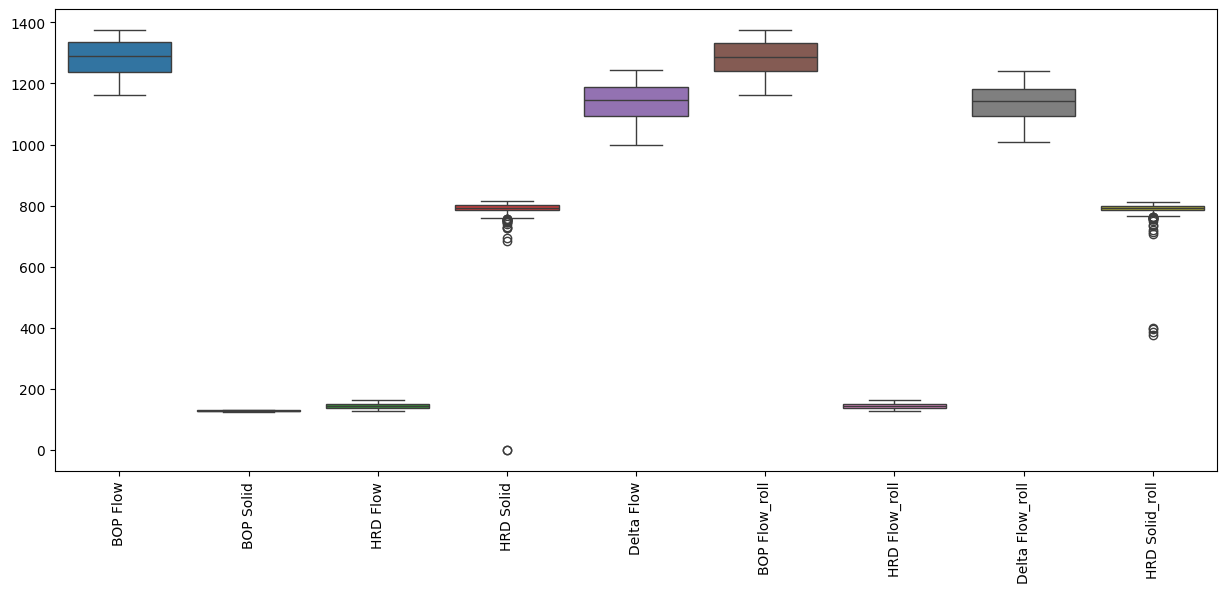

In [218]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
sns.boxplot(data=df_hrd301.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.show()

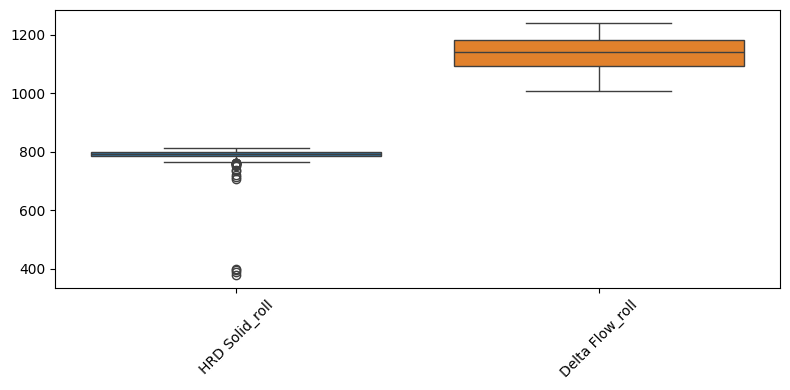

In [219]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only the required columns
cols = ['HRD Solid_roll', 'Delta Flow_roll']

plt.figure(figsize=(8,4))
sns.boxplot(data=df_hrd301[cols])

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Bivariant Analysis

In [220]:
df_hrd301 = df_hrd301[df_hrd301['HRD Solid_roll'] > 785.458333]

In [221]:
df_hrd301 = df_hrd301[df_hrd301['HRD Solid_roll'] < 799.500000]

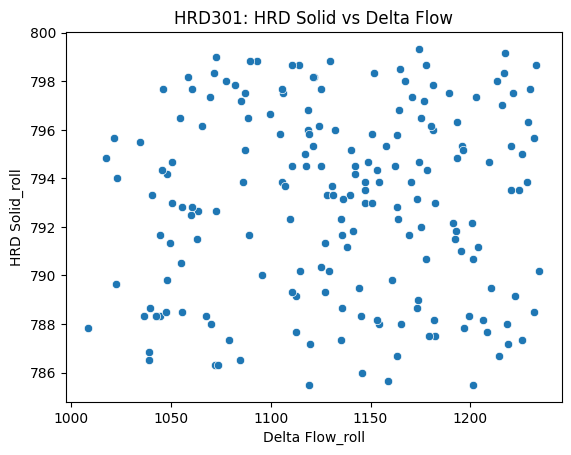

In [222]:
import matplotlib.pyplot as plt
import seaborn as sns

# HRD Solid vs Delta
plt.figure()
sns.scatterplot(data=df_hrd301, x='Delta Flow_roll', y='HRD Solid_roll')
plt.title('HRD301: HRD Solid vs Delta Flow')
plt.show()

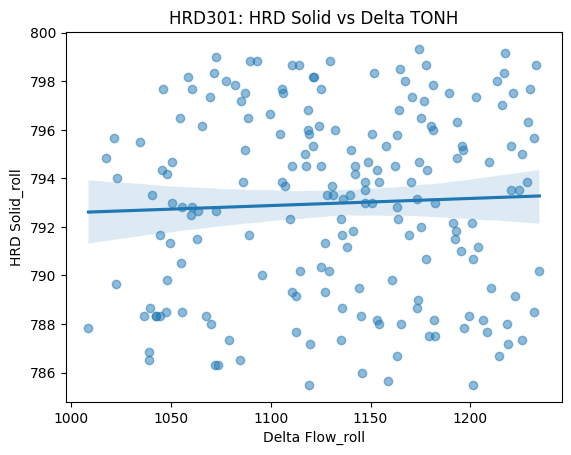

In [226]:
sns.regplot(
    data=df_hrd301,
    x='Delta Flow_roll',
    y='HRD Solid_roll',
    scatter_kws={'alpha':0.5}
)
plt.title('HRD301: HRD Solid vs Delta TONH')
plt.show()

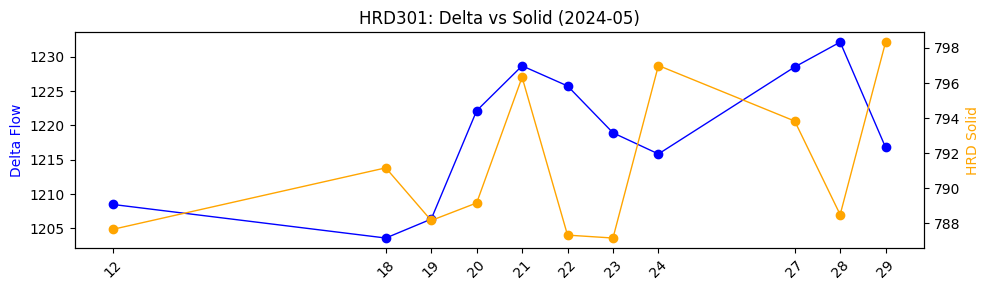

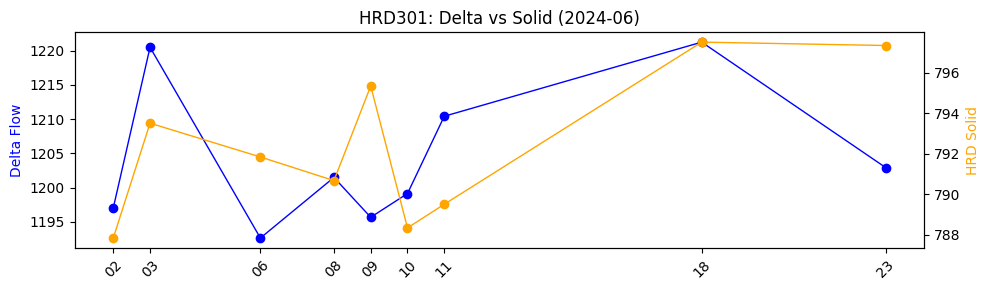

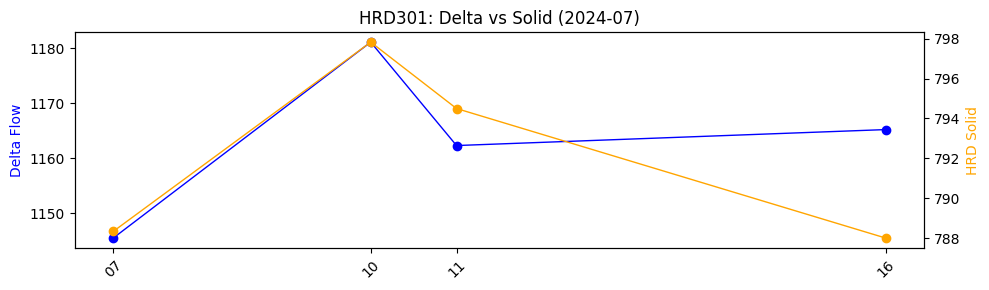

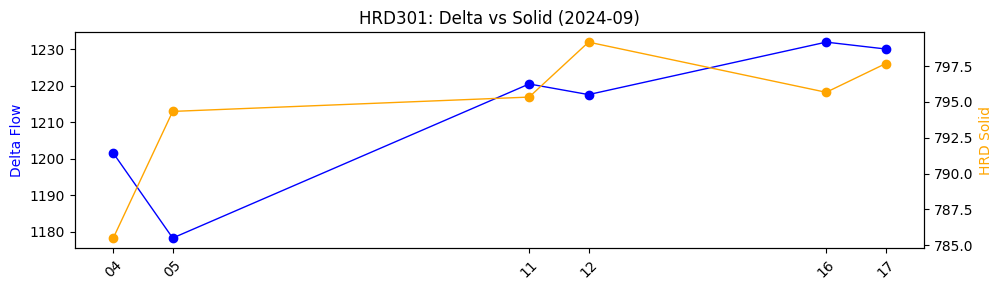

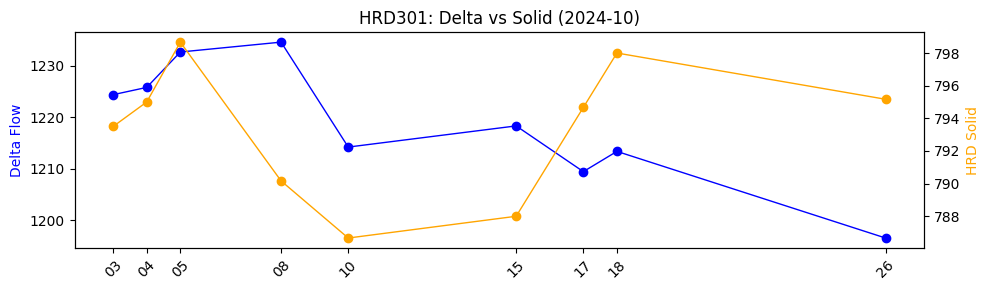

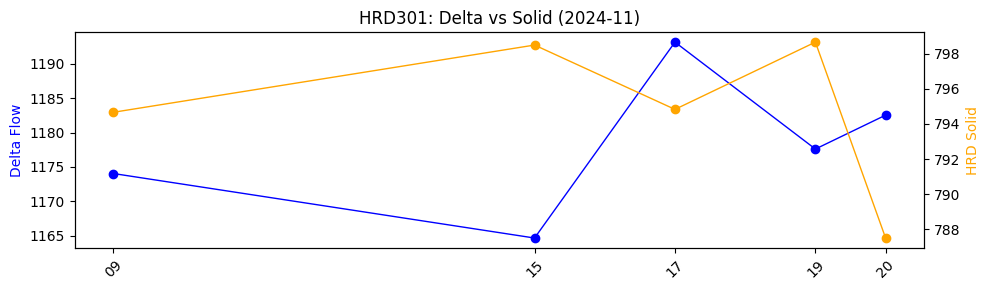

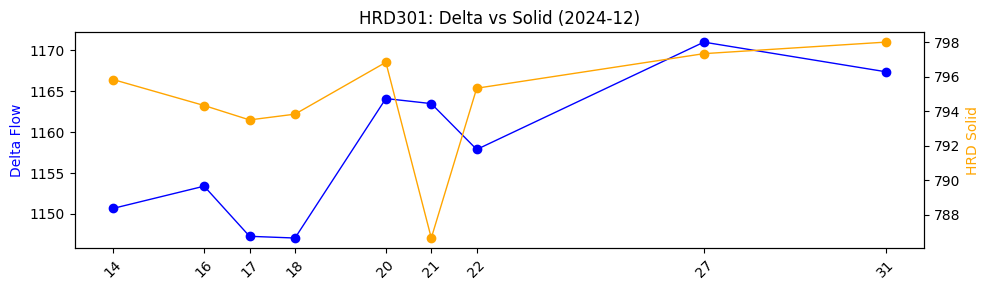

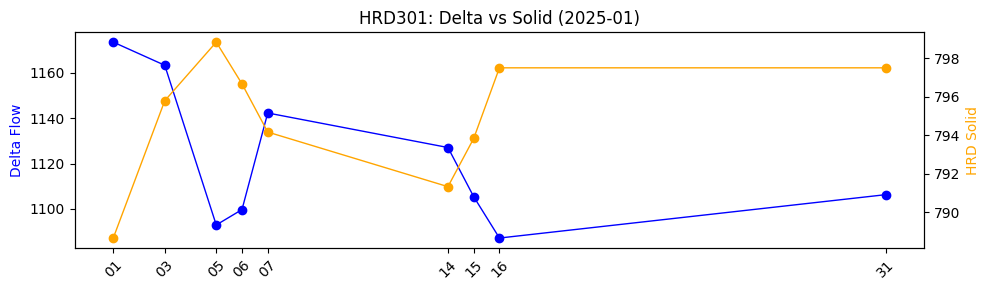

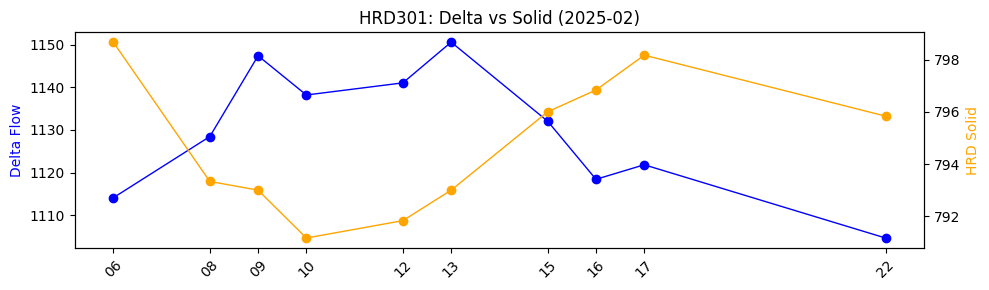

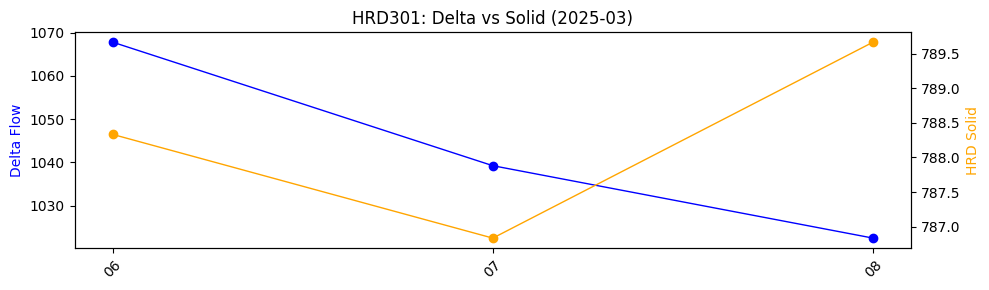

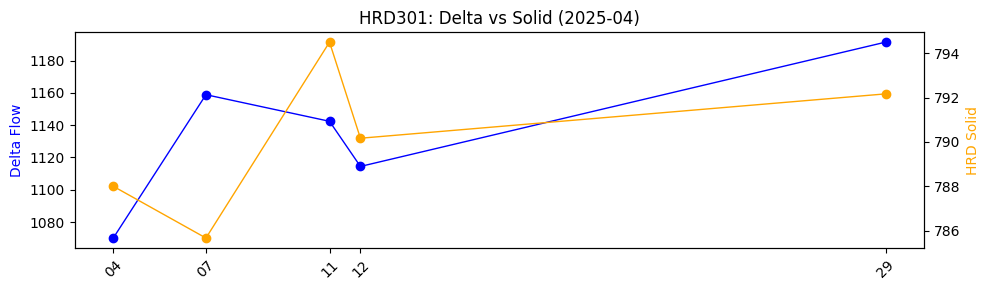

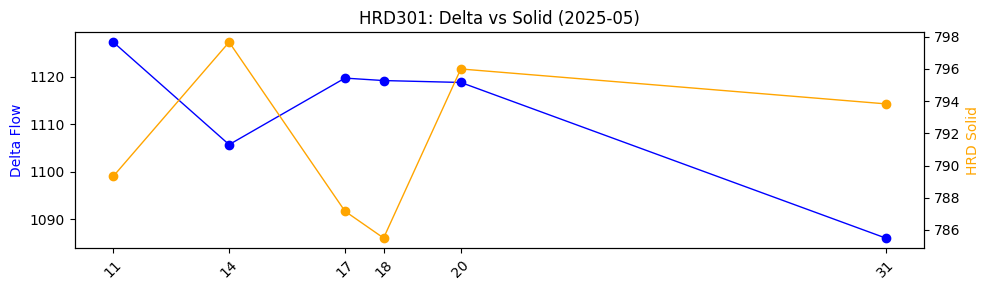

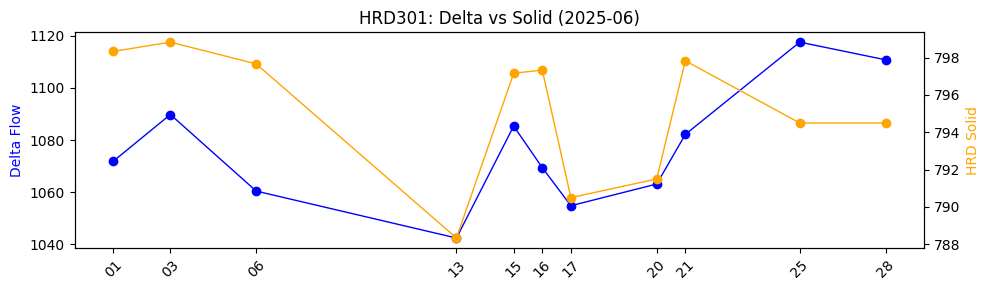

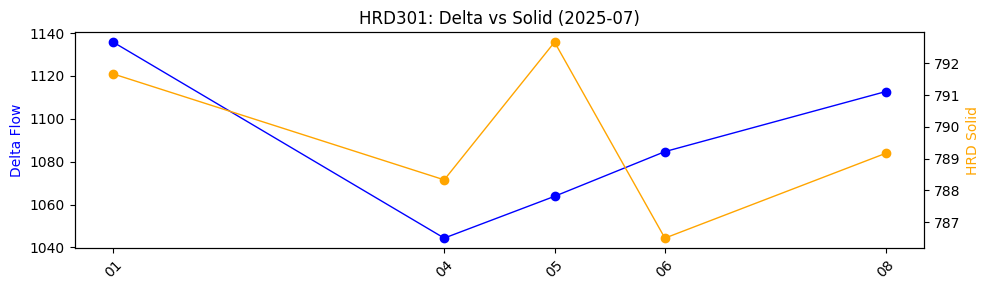

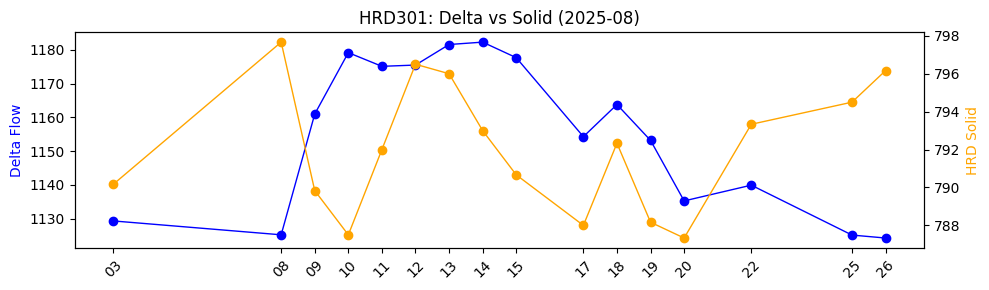

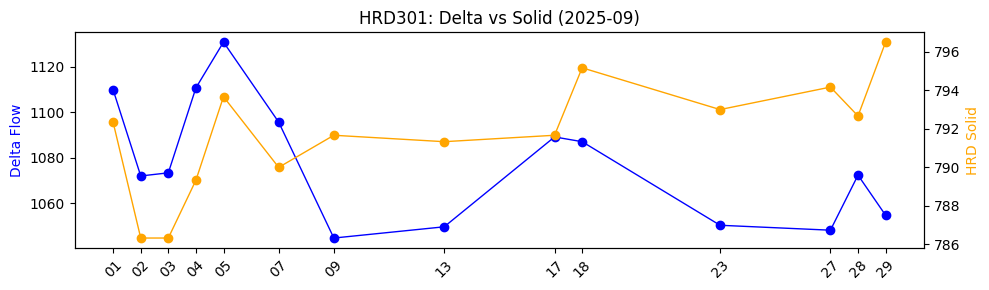

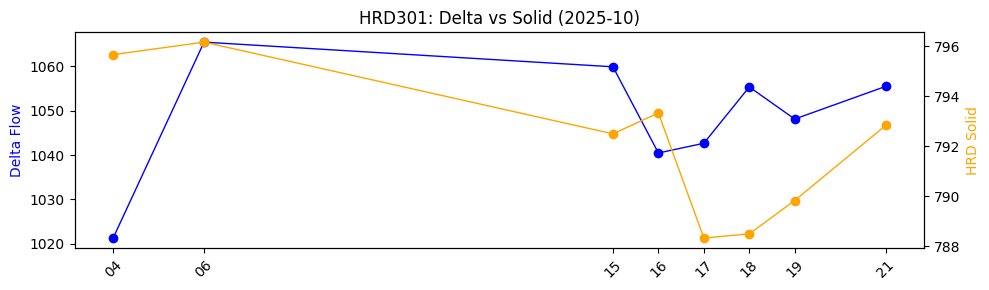

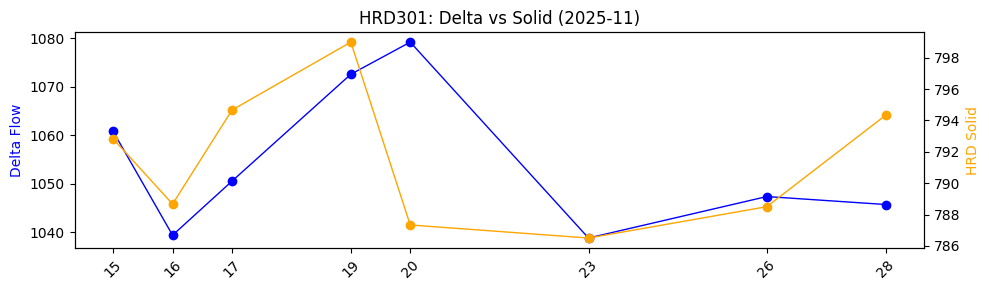

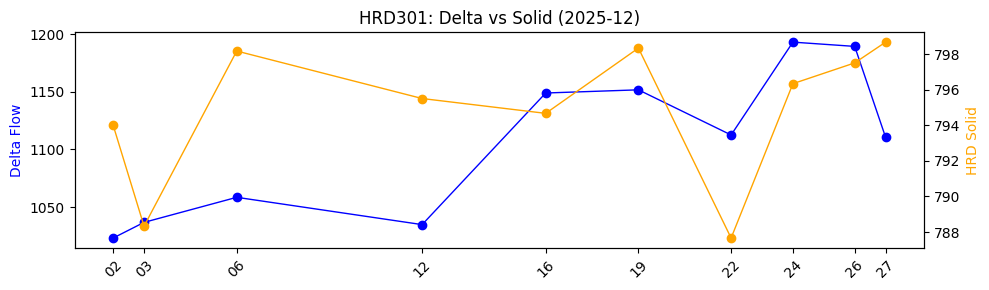

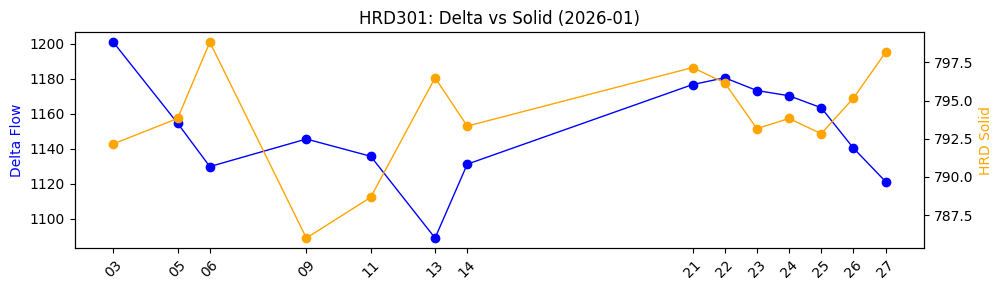

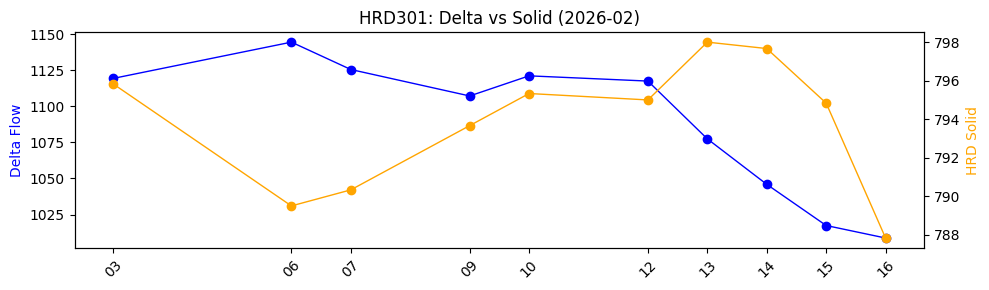

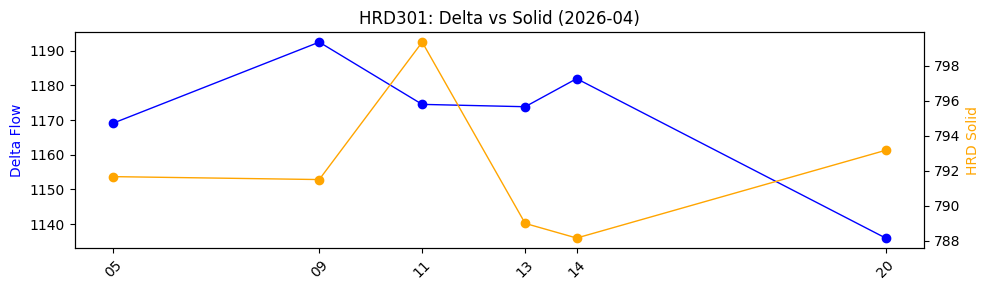

In [224]:
#HRD301
df_hrd301['YearMonth'] = df_hrd301['Date'].dt.to_period('M')

import matplotlib.pyplot as plt

for month, data in df_hrd301.groupby('YearMonth'):

    if data.shape[0] < 2:
        continue   # skip empty/small months

    fig, ax1 = plt.subplots(figsize=(10,3))

    # ✅ Delta Flow with markers
    ax1.plot(
        data['Date'],
        data['Delta Flow_roll'],
        color='blue',
        marker='o',        # 👈 important
        linewidth=1
    )
    ax1.set_ylabel("Delta Flow", color='blue')

    # ✅ HRD Solid with markers
    ax2 = ax1.twinx()
    ax2.plot(
        data['Date'],
        data['HRD Solid_roll'],
        color='orange',
        marker='o',        # 👈 important
        linewidth=1
    )
    ax2.set_ylabel("HRD Solid", color='orange')

    # ✅ Force daily ticks
    ax1.set_xticks(data['Date'])
    ax1.set_xticklabels(data['Date'].dt.strftime('%d'), rotation=45)

    plt.title(f"HRD301: Delta vs Solid ({month})")

    plt.tight_layout()
    plt.show()

In [733]:
corr_value = df_hrd301[['HRD Solid_roll', 'Delta Flow_roll']].corr()

print(corr_value)

                 HRD Solid_roll  Delta Flow_roll
HRD Solid_roll         1.000000         0.045233
Delta Flow_roll        0.045233         1.000000
